# SIG742 2026T2 Assignment 2 Starter Notebook: Group Forecasting Project

<div style="border: 3px solid #1d4ed8; padding: 0.9rem 1rem; border-radius: 6px; background: #eff6ff;">
<strong>Forecasting Performance Determines Your Final Grade Band</strong>
<p>Your Forecasting Performance Grade determines the grade band for your final A2 mark.</p>
<ul>
<li><strong>Forecasting measures:</strong> The grade is determined primarily by MASE. MAPE is used as supporting cross-check evidence.</li>
<li><strong>Questions Q1-Q7:</strong> Your marks for these questions determine the exact final mark within the grade band.</li>
<li><strong>Grade bands:</strong> HD: 80-100; D: 70-79; C: 60-69; P: 50-59; F: 0-49.</li>
</ul>
<p>For example, if your Forecasting Performance Grade is D, your final A2 mark will be between 70 and 79, with the exact mark determined by your marks for Questions Q1-Q7.</p>
</div>

Complete this notebook for Assignment 2. Preserve the required headings, function names, object names, and written-answer markers.

<div style="border: 2px solid #b91c1c; padding: 0.9rem 1rem; border-radius: 6px; background: #fef2f2;">
<strong>Required autograding markers</strong>
<p>Do not delete, rename, edit, move, or reorder any <code>A2:ANSWER</code> START/END marker comment. Write each response between the matching markers for that question. Changed or missing markers may prevent a response from being detected correctly during marking.</p>
</div>


## Group Details

Complete the group details before submission. Follow the Olympus Assignment requirements for peer/self-review and contribution material.

`email_username` is the part before `@deakin.edu.au`; for example, use `xyz` for `xyz@deakin.edu.au`. If your group has more or fewer than three members because of an approved arrangement, adjust the `members` list and explain this in the contribution/video evidence.


In [ ]:
GROUP_INFO = {
    "group_id": "T10",
    "group_name": "T10",
    "members": [
        {
            "student_id": "s226484582",
            "name": "Rajesh Kumar Dash",
            "deakin_email": "s226484582@deakin.edu.au",
            "email_username": "s226484582",
            "role_or_contribution": "Created model for  arima and Sarima and  contribution to EDA and suggested holt_winters",
        },
        {
            "student_id": "",
            "name": "",
            "deakin_email": "",
            "email_username": "",
            "role_or_contribution": "",
        },
        {
            "student_id": "",
            "name": "",
            "deakin_email": "",
            "email_username": "",
            "role_or_contribution": "",
        },
    ],
    "unit": "SIG742",
    "assignment": "A2",
    "teaching_period": "2026T2",
}


In [125]:
A2_REQUIRED_OBJECTS = [
    "GROUP_INFO",
    "raw_tourism_data",
    "training_actual_wide_to_2023M02",
    "validation_actual_wide_2023M03_2023M07",
    "public_history_wide_to_2023M07",
    "baseline_lag1_validation_forecast_wide",
    "baseline_lag12_validation_forecast_wide",
    "baseline_lag1_validation_audit",
    "baseline_lag12_validation_audit",
    "baseline_validation_comparison",
    "baseline_validation_summary",
    "tourism_series_long",
    "modelling_data_or_feature_table",
    "external_feature_log",
    "validation_forecasts",
    "validation_metrics",
    "model_summary",
    "forecast_submission_wide",
    "forecast_submission_audit",
]

A2_REQUIRED_FUNCTIONS = [
    "generate_naive_forecast_wide",
    "validate_forecast_actual_wide",
    "evaluate_forecast_wide",
]


## Required scaffold names and forecasting pipeline

Do not delete or rename required functions, objects, question headings, or written-answer markers. You may add helper cells, functions, models, packages, and intermediate variables.

Key required objects:

| Name | Meaning |
| --- | --- |
| `GROUP_INFO` | Group/member metadata, including Deakin email and email username. |
| `raw_tourism_data` | Public `ISF-TDF2023` dataset loaded into Python. |
| `training_actual_wide_to_2023M02` | Training actuals up to validation cutoff `2023M02`. |
| `validation_actual_wide_2023M03_2023M07` | Visible validation actual/result table. |
| `public_history_wide_to_2023M07` | Public history available at final cutoff `2023M07`. |
| `baseline_validation_comparison` | Destination-level MAE, MASE, MAPE, denominator diagnostics, and row counts for both required baselines. |
| `baseline_validation_summary` | Aggregate validation measures for both required baselines. |
| `tourism_series_long` | Long-format DataFrame with at least `Date`, `destination`, and `demand`. |
| `modelling_data_or_feature_table` | Cutoff-safe modelling data, feature table, or concise model-ready evidence summary. |
| `external_feature_log` | Fixed-column external-source DataFrame, or a zero-row DataFrame with those columns if no external data is used. |
| `validation_forecasts` | Long-format validation forecast DataFrame using `VALIDATION_FORECAST_COLUMNS`. |
| `validation_metrics` | Destination-level validation measure DataFrame using `VALIDATION_METRIC_COLUMNS`. |
| `model_summary` | One-row-per-model DataFrame using `MODEL_SUMMARY_COLUMNS`. |
| `forecast_submission_wide` | Final 12-row all-20 destination forecast table exported directly to CSV. |
| `forecast_submission_audit` | Fixed-key Q2 forecast-only audit for the final wide forecast table. |

Pipeline: Q1 creates naive wide baselines; Q2 audits schema/alignment; Q3 calculates measures; integrated Part I evidence creates baseline tables; Q4 develops models; Q5 exports final forecasts; Q6 interprets performance and markets; Q7 demonstrates reproducibility and collaboration.

## Assignment overview

Build a reproducible forecasting workflow for the public TULIP Lab `ISF-TDF2023` tourism demand dataset. Forecast all 20 destination series for `2023M08` to `2024M07`, analyse selected markets, and submit a wide-format forecast CSV with one row per forecast month.

Assessment structure: Part I functions 15 marks, Part II forecasting project 70 marks, compulsory group video 15 marks. Any forecasting method is allowed if it is cutoff-safe, reproducible, stable enough for assessment, and interpretable.

<div style="border: 2px solid #475569; padding: 0.9rem 1rem; border-radius: 6px; background: #f8fafc;">
<strong>Reproducibility and Stability</strong>
<p>The notebook should rerun from a clean runtime, preserve required names, document inputs and seeds where relevant, regenerate the final CSV from `forecast_submission_wide`, and avoid local absolute paths, manual CSV edits, placeholder forecasts, or uncontrolled stochastic outputs.</p>
</div>

Final output: `forecast_submission_wide` with one `Date` column, exactly 12 rows for `2023M08` to `2024M07`, and exactly the 20 public-dataset destination columns. Export the final CSV directly from this object with `index=False`.

Performance measures: MASE and MAPE are both required. MAE is used where needed to support MASE numerator checking. See the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) for definitions and worked examples. See the [A2 Function Examples Guide](SIG742-2026T2-A2-Function-Examples.md) for detailed Q1-Q3 toy inputs, expected outputs, and function I/O examples.


## Setup and dataset loading

This section provides a Google Colab / online execution option using a public raw URL. You may add a local execution option if your group uses a cloned repository, but do not rely on absolute local paths.


In [126]:
# All imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)


In [127]:
DATA_URL = "https://raw.githubusercontent.com/tulip-lab/open-data/main/ISF-TDF2023/ISF-TDF2023.csv"

TRAIN_END = "2023M02"
VALIDATION_MONTHS = [f"2023M{month:02d}" for month in range(3, 8)]
VALIDATION_START = VALIDATION_MONTHS[0]
VALIDATION_END = VALIDATION_MONTHS[-1]
FORECAST_MONTHS = [f"2023M{month:02d}" for month in range(8, 13)] + [f"2024M{month:02d}" for month in range(1, 8)]
FORECAST_START = FORECAST_MONTHS[0]
FORECAST_END = FORECAST_MONTHS[-1]
FINAL_FORECAST_MONTHS = FORECAST_MONTHS

FOCUS_REQUIRED_DESTINATIONS = ["Australia", "Japan"]
FINAL_FORECAST_DATE_COLUMN = "Date"

Q2_AUDIT_FIELDS = [
    "is_valid",
    "can_align",
    "forecast_row_count",
    "actual_row_count",
    "expected_row_count",
    "missing_months_in_forecast",
    "missing_months_in_actual",
    "extra_months_in_forecast",
    "extra_months_in_actual_source",
    "missing_destinations_in_forecast",
    "missing_destinations_in_actual",
    "extra_columns_in_forecast",
    "duplicate_forecast_dates",
    "duplicate_actual_dates",
    "missing_forecast_value_count",
    "missing_actual_value_count",
    "nonnumeric_forecast_value_count",
    "nonnumeric_actual_value_count",
    "nonfinite_forecast_value_count",
    "nonfinite_actual_value_count",
]

DESTINATION_METRIC_COLUMNS = [
    "destination",
    "n",
    "mae",
    "mase",
    "mape",
    "denominator",
    "n_denominator_pairs",
    "mase_available",
    "denominator_warning",
]
AGGREGATE_METRIC_FIELDS = [
    "n_destinations",
    "mean_mase",
    "median_mase",
    "mean_mape",
]

EXTERNAL_FEATURE_LOG_COLUMNS = [
    "source_name",
    "source_url_or_reference",
    "local_file_or_url",
    "retrieval_date",
    "publication_or_release_date",
    "latest_observation_used",
    "cutoff_applicable",
    "features_created",
    "transformation_summary",
    "licence_or_access_notes",
]
VALIDATION_FORECAST_COLUMNS = [
    "model_label",
    "Date",
    "destination",
    "forecast",
]
VALIDATION_METRIC_COLUMNS = ["model_label"] + DESTINATION_METRIC_COLUMNS
MODEL_SUMMARY_COLUMNS = [
    "model_label",
    "model_family",
    "n_destinations",
    "mean_mase",
    "median_mase",
    "mean_mape",
    "selected",
    "selection_rationale",
    "reproducibility_notes",
    "stability_notes",
]

BASELINE_COMPARISON_COLUMNS = [
    "model_label",
    "lag",
] + DESTINATION_METRIC_COLUMNS
BASELINE_SUMMARY_COLUMNS = [
    "model_label",
    "lag",
] + AGGREGATE_METRIC_FIELDS

In [128]:
# Option A: Google Colab / online execution.
raw_tourism_data = pd.read_csv(DATA_URL)

# Option B: local execution, if you have deliberately saved a local copy.
# local_path = Path("data") / "ISF-TDF2023.csv"
# raw_tourism_data = pd.read_csv(local_path)

DESTINATION_COLUMNS = [column for column in raw_tourism_data.columns if column != FINAL_FORECAST_DATE_COLUMN]
FINAL_FORECAST_COLUMNS = [FINAL_FORECAST_DATE_COLUMN] + DESTINATION_COLUMNS
REQUIRED_DESTINATIONS = DESTINATION_COLUMNS

# Info of the raw tourism data
raw_tourism_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427 entries, 0 to 426
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             427 non-null    object 
 1   Canada           259 non-null    float64
 2   Chile            124 non-null    float64
 3   Mexico           223 non-null    float64
 4   Taiwan China     181 non-null    float64
 5   Hong Kong China  295 non-null    float64
 6   Japan            319 non-null    float64
 7   South Korea      307 non-null    float64
 8   Macao China      295 non-null    float64
 9   Maldives         304 non-null    float64
 10  Cambodia         247 non-null    float64
 11  Indonesia        127 non-null    float64
 12  Singapore        259 non-null    float64
 13  New Zealand      259 non-null    float64
 14  USA              283 non-null    float64
 15  Thailand         337 non-null    float64
 16  Turkey           331 non-null    float64
 17  Australia       

In [129]:
# Inspect the first and last few rows during your own work.
print(raw_tourism_data.head())
print('#'*50)
print(raw_tourism_data.tail())

      Date  Canada  Chile  Mexico  Taiwan China  Hong Kong China  Japan  South Korea  Macao China  Maldives  Cambodia  Indonesia  \
0  1989M01     NaN    NaN     NaN           NaN              NaN    NaN          NaN          NaN       NaN       NaN        NaN   
1  1989M02     NaN    NaN     NaN           NaN              NaN    NaN          NaN          NaN       NaN       NaN        NaN   
2  1989M03     NaN    NaN     NaN           NaN              NaN    NaN          NaN          NaN       NaN       NaN        NaN   
3  1989M04     NaN    NaN     NaN           NaN              NaN    NaN          NaN          NaN       NaN       NaN        NaN   
4  1989M05     NaN    NaN     NaN           NaN              NaN    NaN          NaN          NaN       NaN       NaN        NaN   

   Singapore  New Zealand  USA  Thailand  Turkey  Australia  Hawaii  Austria  Czech  
0        NaN          NaN  NaN       NaN     NaN     1660.0   532.0      NaN    NaN  
1        NaN          NaN  NaN     

#### Observations:
-  We can see the Date is object format and not in datetime format but qs per instructions we can take it as period
-  We can see there are many missing value .We will be digging further on this

In [130]:
# utility function to convert month label to period
def month_label_to_period(month_label):
    if pd.isna(month_label):
        return pd.NaT
    return pd.Period(str(month_label).replace("M", "-"), freq="M")


def calculate_mae(actual_values, forecast_values):
    """Return MAE and the number of valid finite value pairs."""
    actual = pd.to_numeric(pd.Series(actual_values), errors="coerce").to_numpy(dtype=float)
    forecast = pd.to_numeric(pd.Series(forecast_values), errors="coerce").to_numpy(dtype=float)
    if len(actual) != len(forecast):
        raise ValueError("actual_values and forecast_values must have equal length.")
    valid_pairs = np.isfinite(actual) & np.isfinite(forecast)
    n = int(valid_pairs.sum())
    mae = (
        float(np.mean(np.abs(actual[valid_pairs] - forecast[valid_pairs])))
        if n else np.nan
    )
    return mae, n


def calculate_mape(actual_values, forecast_values):
    """Return MAPE and its valid-pair count, excluding zero actuals."""
    actual = pd.to_numeric(pd.Series(actual_values), errors="coerce").to_numpy(dtype=float)
    forecast = pd.to_numeric(pd.Series(forecast_values), errors="coerce").to_numpy(dtype=float)
    if len(actual) != len(forecast):
        raise ValueError("actual_values and forecast_values must have equal length.")
    valid_pairs = np.isfinite(actual) & np.isfinite(forecast) & (actual != 0)
    n_mape = int(valid_pairs.sum())
    mape = (
        float(np.mean(np.abs((actual[valid_pairs] - forecast[valid_pairs]) / actual[valid_pairs])) * 100)
        if n_mape else np.nan
    )
    return mape, n_mape


def calculate_mase_denominator(training_values, naive_lag=1):
    """Return the MASE scale and number of valid lagged training pairs.

    training_values must already be in chronological order. Missing,
    nonnumeric and nonfinite values are excluded pairwise rather than filled.
    """
    if (
        not isinstance(naive_lag, int)
        or isinstance(naive_lag, bool)
        or naive_lag <= 0
    ):
        raise ValueError("naive_lag must be a positive integer.")

    numeric_values = pd.to_numeric(
        pd.Series(training_values),
        errors="coerce",
    ).to_numpy(dtype=float)

    if len(numeric_values) <= naive_lag:
        return np.nan, 0

    current = numeric_values[naive_lag:]
    lagged = numeric_values[:-naive_lag]

    denominator, n_denominator_pairs = calculate_mae(
        current,
        lagged,
    )

    return denominator, n_denominator_pairs

In [131]:
# copy the raw data to a new dataframe for processing
tourisim_df=raw_tourism_data.copy(deep=True)

# convert dataframe to have a PeriodIndex for the Date column, and sort by date
tourisim_df["Date"] = tourisim_df["Date"].map(month_label_to_period)
tourisim_df = tourisim_df.sort_values("Date").reset_index(drop=True)
countries = [c for c in tourisim_df.columns if c != "Date"]

# Print shape, date range, and destinations
print("Shape:", tourisim_df.shape)

print("Date range:", tourisim_df["Date"].min(), "to", tourisim_df["Date"].max())

print("Destinations:", countries)

Shape: (427, 21)
Date range: 1989-01 to 2024-07
Destinations: ['Canada', 'Chile', 'Mexico', 'Taiwan China', 'Hong Kong China', 'Japan', 'South Korea', 'Macao China', 'Maldives', 'Cambodia', 'Indonesia', 'Singapore', 'New Zealand', 'USA', 'Thailand', 'Turkey', 'Australia', 'Hawaii', 'Austria', 'Czech']


In [132]:
# Show the first few rows of the processed tourism data
tourisim_df.head()

,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
0,1989-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1660.0,532.0,NaN,NaN
1,1989-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3090.0,1550.0,NaN,NaN
2,1989-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2570.0,822.0,NaN,NaN
3,1989-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1580.0,1010.0,NaN,NaN
4,1989-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1850.0,1383.0,NaN,NaN


In [133]:
# we will only consider data up to July 2023 for analysis as after that we have forcast
cutoff_period = month_label_to_period("2023-07")
tourisim_df = tourisim_df[tourisim_df["Date"] <= cutoff_period].copy()

# Calculate missing values and percentage for each destination
missing_df=(tourisim_df[countries].isna().sum()
            .sort_values(ascending=False)
            .reset_index(name='missing_values')
            .rename(columns={'index': 'destination'}))
missing_df['pct'] = ((missing_df['missing_values'] / len(tourisim_df)) * 100).round(1)

# Get first min date and max date to see the start and end of the valid data for each destination
missing_df["first_valid"] = [
    tourisim_df.loc[tourisim_df[c].notna(), "Date"].min() if tourisim_df[c].notna().any() else None
    for c in countries
]
missing_df["last_valid"] = [
    tourisim_df.loc[tourisim_df[c].notna(), "Date"].max() if tourisim_df[c].notna().any() else None
    for c in countries
]

missing_df


,destination,missing_values,pct,first_valid,last_valid
0,Chile,291,70.1,2002-01,2023-07
1,Indonesia,288,69.4,2012-01,2023-07
2,Czech,276,66.5,2005-01,2023-07
3,Taiwan China,234,56.4,2008-07,2023-07
4,Mexico,192,46.3,1999-01,2023-07
5,Austria,172,41.4,1997-01,2023-07
6,Cambodia,168,40.5,1998-01,2023-07
7,New Zealand,156,37.6,1999-01,2023-07
8,Singapore,156,37.6,1998-01,2023-07
9,Canada,156,37.6,2003-01,2023-07


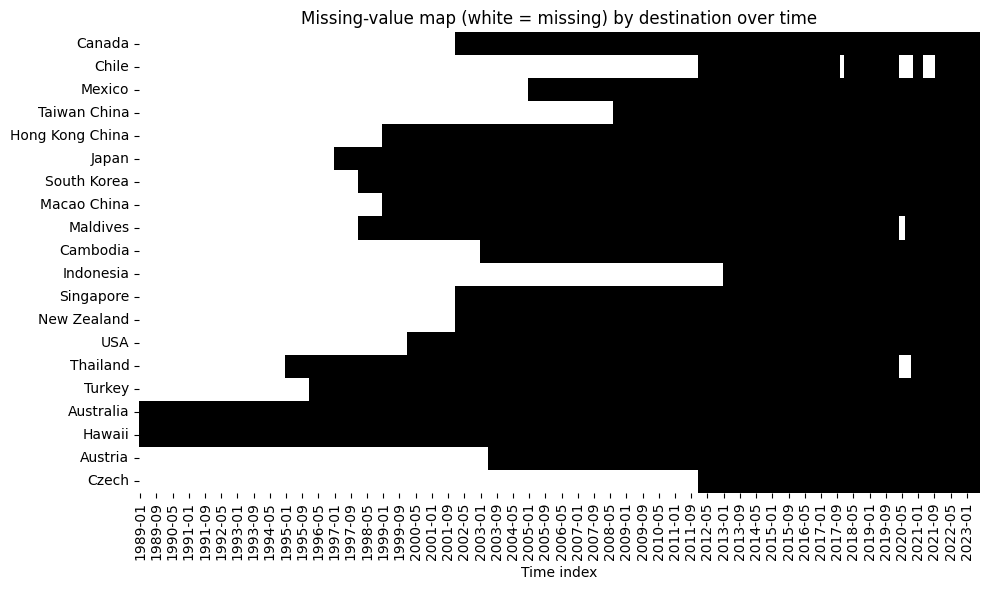

In [134]:
# Plot a heat map to visualize missing values over time for each destination
plt.figure(figsize=(10, 6))
sns.heatmap(tourisim_df.set_index("Date")[countries].isna().T, cbar=False, cmap="Greys_r")
plt.title("Missing-value map (white = missing) by destination over time")
plt.xlabel("Time index")
plt.tight_layout()
plt.show()


### Observations:
-  Each country has a celna start month and is 100% present after that (eg:chile beings on 20212-01,Czech 2012-01 Taiwan 2008-07)
-  Only three countries have some ramnge gaps (chile ,Thailand,Maldives).Everyone else is either fully dense form their start date or fully missing before it.So imputation matters for these three only
- Series lengths differ a lot — some destinations (e.g. Australia, Hawaii) have near-complete history back to 1989, while others (Chile, Indonesia, Czech, Taiwan) only start being tracked from the 2000s/2010s.


In [135]:
# Define periods for analysis
periods = {
    "pre_covid": (tourisim_df["Date"] < pd.Period("2020-03", freq="M")),
    "covid_disruption": (tourisim_df["Date"] >= pd.Period("2020-03", freq="M")) &
                       (tourisim_df["Date"] <= pd.Period("2022-06", freq="M")),
    "early_recovery": (tourisim_df["Date"] >= pd.Period("2022-07", freq="M")) &
                     (tourisim_df["Date"] <= pd.Period("2023-02", freq="M")),
    "validation": (tourisim_df["Date"] >= pd.Period("2023-03", freq="M")) &
                  (tourisim_df["Date"] <= pd.Period("2023-07", freq="M")),
}

# Calculate preconvid covid disruption and early recovery means for each destination
period_means = pd.DataFrame({
    name: tourisim_df.loc[mask, countries].mean(numeric_only=True)
    for name, mask in periods.items()
})

period_means["pct_drop_covid_vs_precovid"] = (
    (period_means["covid_disruption"] - period_means["pre_covid"]) / period_means["pre_covid"] * 100
).round(1)

period_means["pct_recovery_vs_precovid"] = (
    (period_means["early_recovery"] - period_means["pre_covid"]) / period_means["pre_covid"] * 100
).round(1)

period_means.round(1).sort_values("pct_recovery_vs_precovid")

,pre_covid,covid_disruption,early_recovery,validation,pct_drop_covid_vs_precovid,pct_recovery_vs_precovid
Taiwan China,214022.8,1206.3,4659.1,16224.6,-99.4,-97.8
Hong Kong China,2045746.2,7089.4,212947.9,2339237.2,-99.7,-89.6
Japan,190017.7,5914.9,23525.8,168081.2,-96.9,-87.6
South Korea,207967.4,12359.6,27874.6,140073.6,-94.1,-86.6
Singapore,144471.1,5177.8,19978.2,118369.4,-96.4,-86.2
Austria,35712.9,905.1,4968.1,14833.4,-97.5,-86.1
New Zealand,17469.7,254.8,2969.4,10299.6,-98.5,-83.0
Indonesia,124284.5,4767.8,21672.6,64229.8,-96.2,-82.6
Czech,46453.6,1965.2,8474.2,14912.4,-95.8,-81.8
Hawaii,4986.8,481.6,909.6,1117.2,-90.3,-81.8


### Observations:
Nearly every destination is still below precovid demand by the early recovery windows(Most are 55-98% down) except Mexico and Turkey may be due to visa process

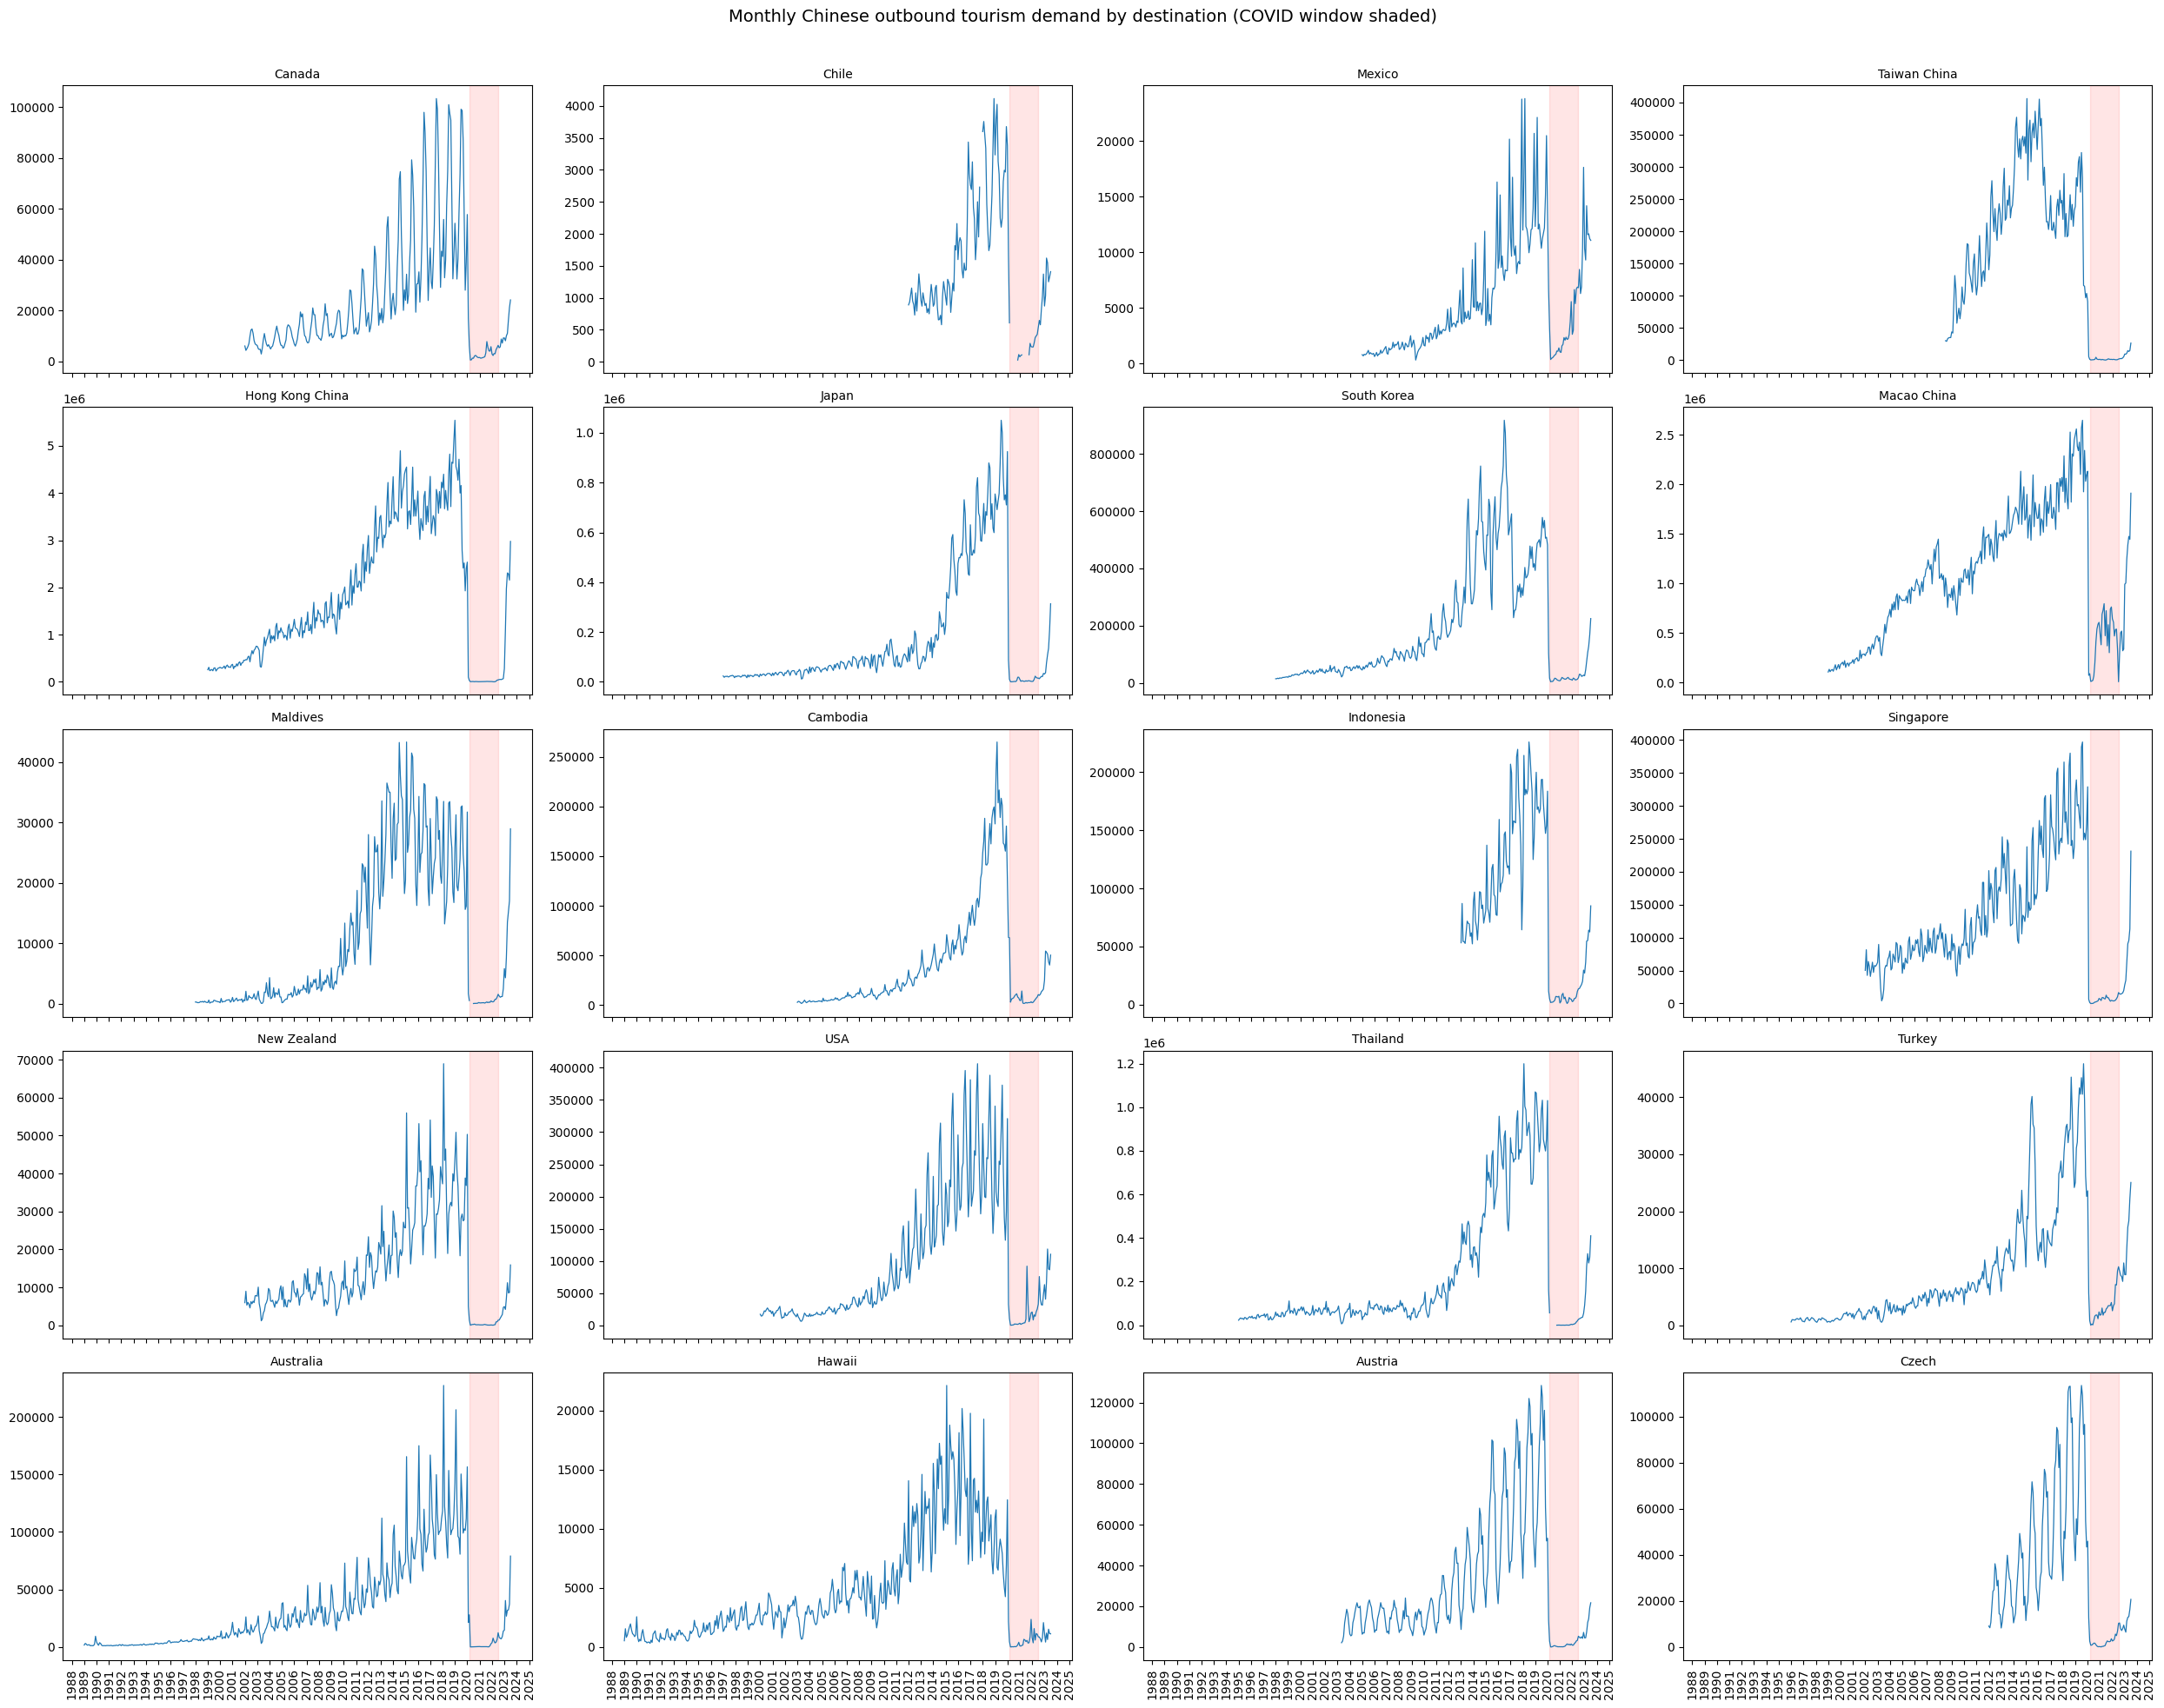

In [136]:
# Prepare data for plotting
plot_df = tourisim_df.assign(Date_dt=tourisim_df["Date"].dt.to_timestamp())

# Plot monthly tourism demand for each destination, highlighting the COVID disruption period

fig, axes = plt.subplots(5, 4, figsize=(25, 20), sharex=True)

for ax, c in zip(axes.flat, countries):
    ax.plot(plot_df["Date_dt"], plot_df[c], linewidth=0.9)
    ax.set_title(c, fontsize=10)
    ax.axvspan(
        pd.Timestamp("2020-03-01"),
        pd.Timestamp("2022-06-30"),
        color="red",
        alpha=0.1
    )
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelrotation=90)
fig.suptitle(
    "Monthly Chinese outbound tourism demand by destination (COVID window shaded)",
    fontsize=14,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### Observations:
- All destination show a clear precovid. upward trend and then a sharp drop during the red shaded covid
- We cna see recovery after  2022 but did not return to pre civid level
- Some destinations like Mexico and Turkey reciver faster then others
- We can see biggest demand swings precovid vs post covid  with markets with laerger abs vilume like Hongkong,Taiwan and others.

['Hong Kong China', 'Macao China', 'Thailand', 'South Korea', 'Japan', 'Taiwan China']


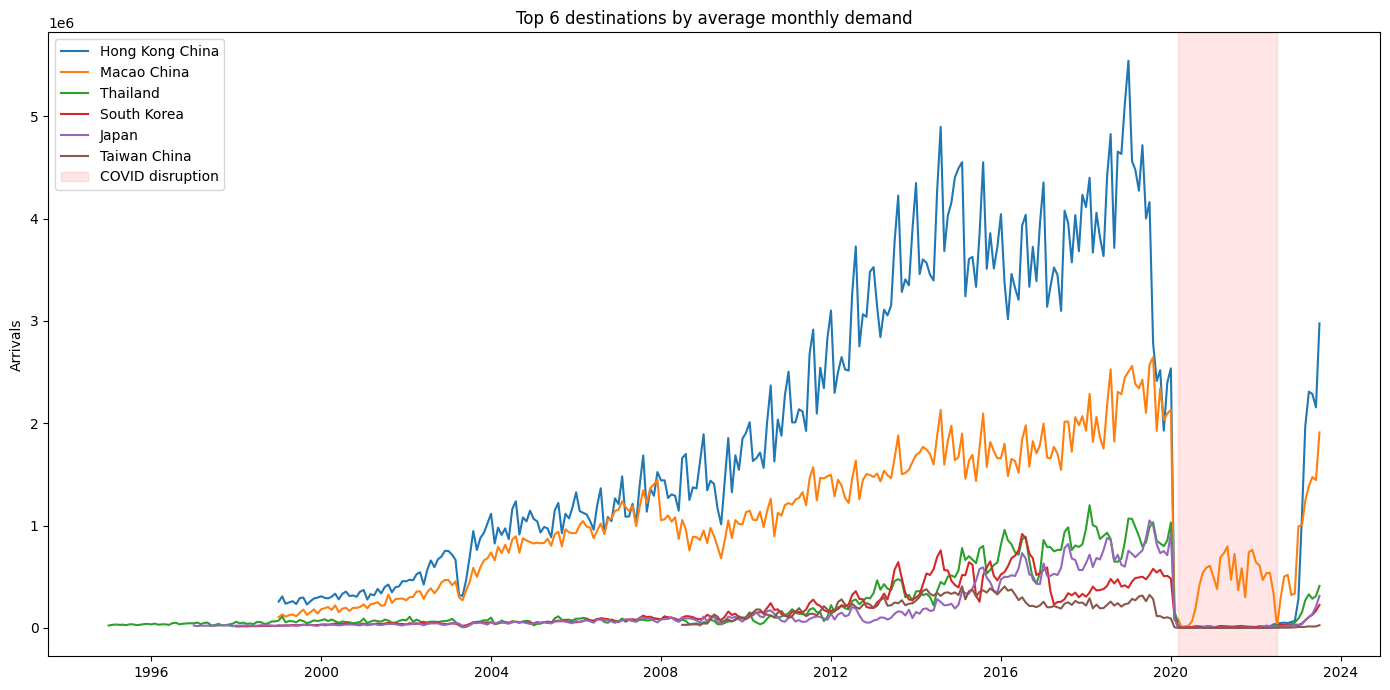

In [137]:
# Descriptive stats
desc = tourisim_df[countries].describe().T
plot_df = tourisim_df.assign(Date_dt=tourisim_df["Date"].dt.to_timestamp())

# get mean and order by desc and take top 6
top_by_volume = desc["mean"].sort_values(ascending=False).index.tolist()
print(top_by_volume[:6])

# Plot top 6 destinations by average monthly demand, highlighting the COVID disruption period
plt.figure(figsize=(14, 7))
for c in top_by_volume[:6]:
    plt.plot(plot_df["Date_dt"], plot_df[c], label=c)
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2022-06-30"), color="red", alpha=0.1, label="COVID disruption")
plt.legend()
plt.title("Top 6 destinations by average monthly demand")
plt.ylabel("Arrivals")
plt.tight_layout()
plt.show()


### Observations:
- We can see for Hong Kong China', 'Macao China', 'Thailand', 'South Korea', 'Japan', 'Taiwan China are top 6 destintaion and we can see all of the destinationd own in covid period

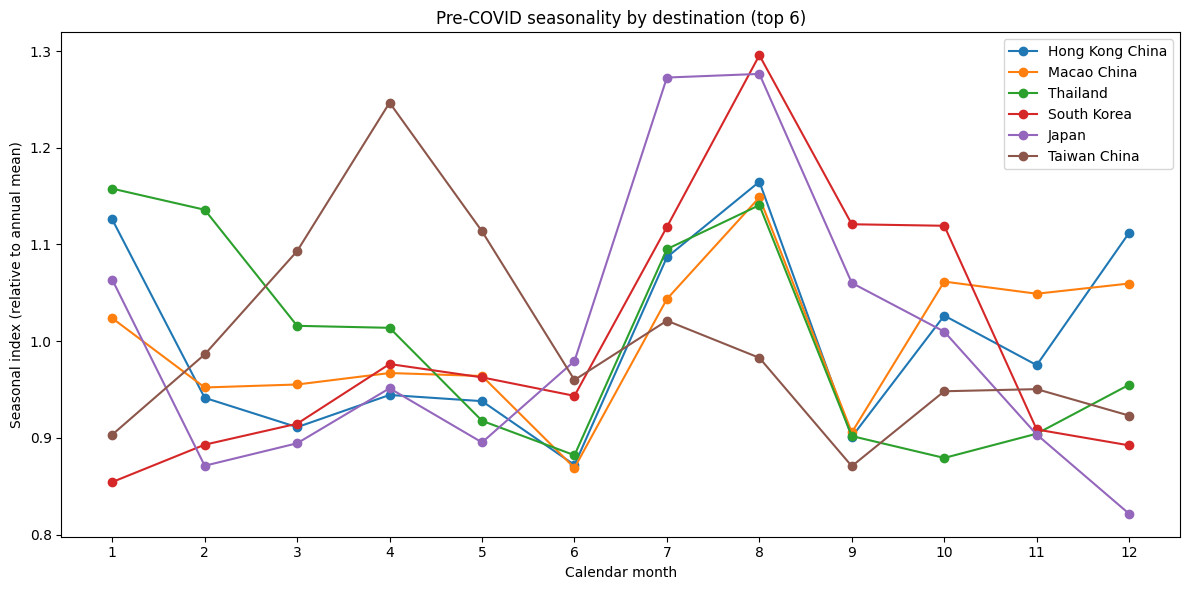

In [138]:
# Get preconvids only data to calculate monthly seasonality for each destination
pre = tourisim_df.loc[periods["pre_covid"]].copy()
pre["Month"] = pre["Date"].dt.month
monthly_seasonality = pre.groupby("Month")[countries].mean()

# check the seasonality for the top 6 destinations by volume
plt.figure(figsize=(12, 6))
for c in top_by_volume[:6]:
    series = monthly_seasonality[c]
    plt.plot(series.index, series / series.mean(), marker="o", label=c)
plt.xlabel("Calendar month")
plt.ylabel("Seasonal index (relative to annual mean)")
plt.title("Pre-COVID seasonality by destination (top 6)")
plt.xticks(range(1, 13))
plt.legend()
plt.tight_layout()
plt.show()


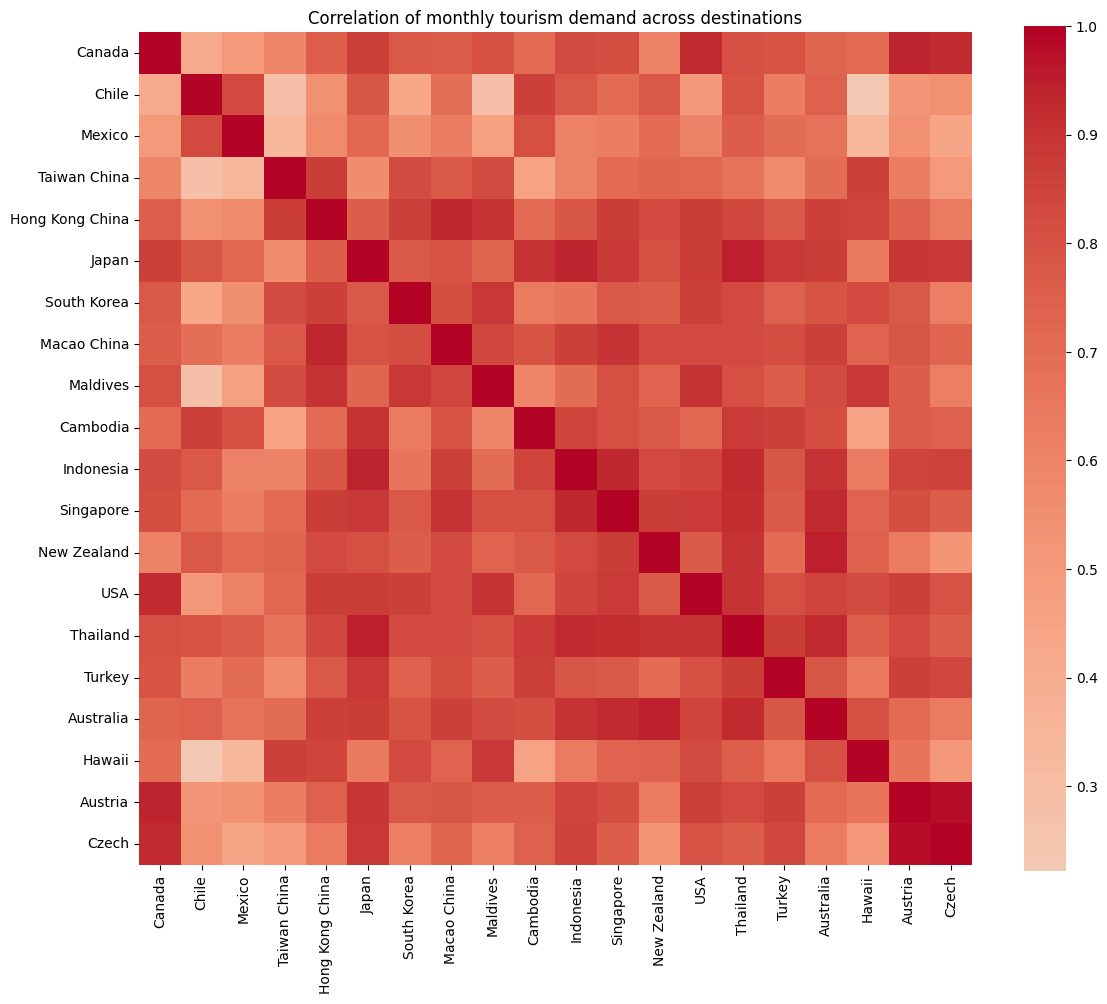

In [139]:
# coeralation of monthly tourism demand across destinations
corr = tourisim_df[countries].corr()

# show heatmap of correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation of monthly tourism demand across destinations")
plt.tight_layout()
plt.show()


### Observations:
- Most destination pairs are positively correlated, since demand from China moves with common macro drivers(economic conditions, currency) 
- Highest correlations tend to be among similarly-sized, geographically close, or
similarly-positioned leisure destinations.




### Validation and final-cutoff split objects

Create these required scaffold objects from `raw_tourism_data` using the `Date` column and the existing constants. Use a real year-month representation such as `pandas.Period(..., freq="M")`; do not filter by direct string comparison on month labels.

- `training_actual_wide_to_2023M02`: used for validation MASE denominators, validation MAPE alignment, and validation baseline generation cutoff.
- `validation_actual_wide_2023M03_2023M07`: visible validation actual/result table used for Q1-Q3 integrated evidence and Q4 validation comparison.
- `public_history_wide_to_2023M07`: public history available for the final forecasting cutoff and final MASE denominator concept; no final-evaluation actual/result values are included.


In [140]:
# Introduce new helper column to indicate the month period for each row in the raw tourism data
raw_tourism_data_with_period = raw_tourism_data.copy()
raw_tourism_data_with_period["_month_period"] = raw_tourism_data_with_period[
    FINAL_FORECAST_DATE_COLUMN
].map(month_label_to_period)
# Training_actual_wide_to_2023M02
training_actual_wide_to_2023M02 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"] <= month_label_to_period(TRAIN_END),
    FINAL_FORECAST_COLUMNS,
].copy()

# validation_actual_wide_2023M03_2023M07

validation_periods = [month_label_to_period(month) for month in VALIDATION_MONTHS]
validation_actual_wide_2023M03_2023M07 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"].isin(validation_periods),
    FINAL_FORECAST_COLUMNS,
].copy()

# historical data up to July 2023 for public use (for model development and validation)
public_history_wide_to_2023M07 = raw_tourism_data_with_period.loc[
    raw_tourism_data_with_period["_month_period"] <= month_label_to_period("2023M07"),
    FINAL_FORECAST_COLUMNS,
].copy()



## Part I: Forecast table generation and evaluation functions

Use the [A2 Function Examples Guide](SIG742-2026T2-A2-Function-Examples.md) for detailed Q1-Q3 input/output examples. Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) for MASE/MAPE definitions and examples.

### Q1. General naive-lag forecast table generator [5 marks]

Implement `generate_naive_forecast_wide(historical_actual_wide, cutoff_label, forecast_months, required_destinations=None, lag=1, date_column="Date")`.

Requirements: accept a wide actual table; return a pandas DataFrame with exactly one row per requested month; use all destination columns when `required_destinations=None`; otherwise forecast exactly the supplied destinations; use only values available at or before `cutoff_label`; support positive integer `lag`, especially `lag=1` and `lag=12`; support arbitrary forecast months and all destinations; compute recursive lag forecasts in chronological month order; avoid string subtraction for month labels.

Return rows in the supplied `forecast_months` order. Return columns in the exact order `date_column`, followed by the inferred or supplied destination order. Do not return an index column, `model_label`, diagnostics, or other extra columns.

Lag rule: for forecast month `m`, use source month `m - lag`. If the source month is after the cutoff but has already been forecast, use that generated forecast recursively. If no source value is available, return `NaN` or raise a clear error.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q1 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q1:START -->
The generator converts month labels to monthly periods, restricts observed sources to the stated cutoff, and calculates requested months chronologically so recursive forecasts are available when needed. It then restores the user-supplied month order and returns only the date and requested destination columns.
<!-- A2:ANSWER:Q1:END -->

#### Optional month-label helper example

This optional helper example only shows one way to convert labels such as `2023M03` into a month-aware representation. You may implement your own helper inside Q1. Do not use string subtraction for month arithmetic.


In [141]:
def period_to_month_label_example(period):
    """ convert a pandas monthly Period back to YYYYMmm."""
    return f"{period.year}M{period.month:02d}"

In [142]:
def generate_naive_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    required_destinations=None,
    lag=1,
    date_column="Date",
):
    """Return the required wide-format naive-lag forecast DataFrame.

    Return exactly one row per requested month in the supplied forecast_months
    order. Return columns as date_column followed by the inferred or supplied
    destination order, with no extra columns. If required_destinations is None,
    use all columns except date_column in historical_actual_wide.

    For each forecast month m, use m - lag months as the source month. Use
    observed values at or before cutoff_label; otherwise use previously generated
    forecasts recursively when available. Raise a clear error if lag is not a
    positive integer. Use month-aware labels, not string subtraction.
    """
    # some defensive checks for the inputs
    if not isinstance(lag, int) or isinstance(lag, bool) or lag <= 0:
        raise ValueError("lag must be a positive integer.")

    if date_column not in historical_actual_wide.columns:
        raise KeyError(f"date_column {date_column!r} not found in historical_actual_wide.")

    if required_destinations is None:
        required_destinations = [
            col for col in historical_actual_wide.columns if col != date_column
        ]
    required_destinations = list(required_destinations)

    missing_destinations = [
        dest for dest in required_destinations if dest not in historical_actual_wide.columns
    ]
    if missing_destinations:
        raise KeyError(f"Missing destination columns: {missing_destinations}")

    cutoff_period = pd.Period(str(cutoff_label).replace("M", "-"), freq="M")

    # get all historical data up to the cutoff period, and convert the date column to Period
    history = historical_actual_wide[[date_column] + required_destinations].copy()
    history[date_column] = history[date_column].map(
        lambda x: pd.Period(str(x).replace("M", "-"), freq="M") if pd.notna(x) else pd.NaT
    )
    history = history.dropna(subset=[date_column]).sort_values(date_column).reset_index(drop=True)

    # build a lookup dictionary for actual values by destination and period
    actual_lookup = {dest: {} for dest in required_destinations}
    for _, row in history.iterrows():
        row_date = row[date_column]
        for dest in required_destinations:
            value = pd.to_numeric(row[dest], errors="coerce")
            if pd.notna(value):
                actual_lookup[dest][row_date] = float(value)

    requested_months = list(forecast_months)
    requested_periods = [
        pd.Period(str(label).replace("M", "-"), freq="M")
        for label in requested_months
    ]
    generated_lookup = {dest: {} for dest in required_destinations}
    generated_rows = {}
    # for each requested forecast month, calculate the source month by subtracting the lag, and look up the value from actuals or previously generated forecasts
    for target_period in sorted(set(requested_periods)):
        row = {}
        for dest in required_destinations:
            source_period = target_period - lag
            value = np.nan
            # recursive naive to go back to actials if the source period is before or equal to the cutoff, 
            # otherwise use previously generated forecasts
            if source_period <= cutoff_period and source_period in actual_lookup[dest]:
                value = actual_lookup[dest][source_period]
            elif source_period in generated_lookup[dest]:
                value = generated_lookup[dest][source_period]

            if pd.notna(value):
                generated_lookup[dest][target_period] = float(value)
            row[dest] = value
        generated_rows[target_period] = row

    output_rows = []
    for month_label, target_period in zip(requested_months, requested_periods):
        output_rows.append({
            date_column: month_label,
            **generated_rows[target_period],
        })
    forecast_df = pd.DataFrame(output_rows, columns=[date_column] + required_destinations)
    return forecast_df


#### Q1 illustrative toy example only

Illustrative toy example only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

These toy checks are illustrative and not exhaustive. Passing these checks does not guarantee full marks; your functions must also satisfy the full assignment specification and work on the required validation and final forecast structures.


In [143]:
q1_toy_historical_actual_wide = pd.DataFrame({
    "Date": ["2022M03", "2022M04", "2022M05", "2022M06", "2022M07", "2023M01", "2023M02"],
    "Australia": [70, 75, 80, 85, 90, 95, 100],
    "Japan": [180, 190, 200, 210, 220, 230, 240],
})

q1_expected_lag1 = pd.DataFrame({
    "Date": ["2023M03", "2023M04", "2023M05"],
    "Australia": [100, 100, 100],
    "Japan": [240, 240, 240],
})

q1_expected_lag12 = pd.DataFrame({
    "Date": ["2023M03", "2023M04", "2023M05"],
    "Australia": [70, 75, 80],
    "Japan": [180, 190, 200],
})

# After implementing generate_naive_forecast_wide, set this to True and compare
# your toy outputs with q1_expected_lag1 and q1_expected_lag12.
RUN_Q1_TOY_CHECKS = True

if RUN_Q1_TOY_CHECKS:
    q1_lag1_output = generate_naive_forecast_wide(
        q1_toy_historical_actual_wide,
        cutoff_label="2023M02",
        forecast_months=["2023M03", "2023M04", "2023M05"],
        lag=1,
    )
    q1_lag12_output = generate_naive_forecast_wide(
        q1_toy_historical_actual_wide,
        cutoff_label="2023M02",
        forecast_months=["2023M03", "2023M04", "2023M05"],
        lag=12,
    )

    pd.testing.assert_frame_equal(
        q1_lag1_output.reset_index(drop=True),
        q1_expected_lag1,
        check_dtype=False,
    )
    pd.testing.assert_frame_equal(
        q1_lag12_output.reset_index(drop=True),
        q1_expected_lag12,
        check_dtype=False,
    )

### Q2. Forecast and actual table validation/alignment [5 marks]

Implement `validate_forecast_actual_wide(forecast_wide_df, actual_wide_df=None, required_months=None, required_destinations=None, date_column="Date")`.

`df` means a pandas DataFrame. Both inputs use a wide table: one row per month, one `Date` column, and one numeric column per destination. This is not a long table.

Modes: forecast-only mode (`actual_wide_df=None`) checks export readiness; forecast-vs-actual mode checks whether forecast and actual/result tables can align by `Date` and destination.

Requirements: check required `Date`, months, destination columns, row counts, duplicate dates, extra rows/columns, missing values, numeric values, finite values, and alignment when actuals are supplied. If `required_destinations=None`, infer destination columns from `forecast_wide_df`, but all-20 evidence must still match `REQUIRED_DESTINATIONS`.

Return a Python dictionary containing every key in `Q2_AUDIT_FIELDS`, in that order. In forecast-only mode, `can_align` and all actual-related fields must be `None`, not omitted. In forecast-vs-actual mode, `actual_row_count` counts actual rows after subsetting to `required_months`; `can_align` reports structural alignment; `is_valid` reports all applicable structure and value-quality checks. Duplicate counts count occurrences after the first occurrence.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q2 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q2:START -->
The audit separates structural alignment from overall validity. `can_align` checks whether the required month-destination keys can be matched, while `is_valid` additionally requires complete, numeric, finite values. Extra months in the actual source are reported but allowed because the actual table is subset to the required evaluation months.
<!-- A2:ANSWER:Q2:END -->

In [144]:
def validate_forecast_actual_wide(
    forecast_wide_df,
    actual_wide_df=None,
    required_months=None,
    required_destinations=None,
    date_column="Date",
):
    """Return the fixed Q2 audit dictionary for wide-table validation.

    Populate every key in Q2_AUDIT_FIELDS. Forecast-only mode uses None for
    can_align and every actual-related field. Forecast-vs-actual mode subsets
    actual_wide_df to required_months before reporting actual_row_count and
    checking structural alignment.
    """
    def count_quality_issues(df, date_col, dest_cols):
        """ Count missing, nonnumeric, and nonfinite values in the specified destination columns of the DataFrame."""
        missing_count = 0
        nonnumeric_count = 0
        nonfinite_count = 0
        for col in dest_cols:
            if col not in df.columns:
                continue
            for value in df[col].tolist():
                if pd.isna(value):
                    missing_count += 1
                    continue
                try:
                    numeric_value = float(value)
                except (TypeError, ValueError):
                    nonnumeric_count += 1
                    continue
                if not np.isfinite(numeric_value):
                    nonfinite_count += 1
        return missing_count, nonnumeric_count, nonfinite_count

   # validate the forecast DataFrame structure and values   
    forecast_df = forecast_wide_df.copy()
    forecast_date_values = forecast_df[date_column].tolist() if date_column in forecast_df.columns else []
    forecast_columns = [col for col in forecast_df.columns if col != date_column]
    # defensive checks for required destinations and months
    if required_destinations is None:
        required_destinations = [col for col in forecast_columns]

    required_destinations = list(required_destinations)
    required_months = list(required_months) if required_months is not None else None

    missing_destinations_in_forecast = [
        dest for dest in required_destinations if dest not in forecast_df.columns
    ]
    extra_columns_in_forecast = [
        col for col in forecast_columns if col not in required_destinations
    ]
    # subset the forecast DataFrame to only include required months, and identify any missing or extra months
    if required_months is None:
        forecast_subset = forecast_df.copy()
        missing_months_in_forecast = []
        extra_months_in_forecast = []
    elif date_column in forecast_df.columns:
        forecast_subset = forecast_df[forecast_df[date_column].isin(required_months)].copy()
        missing_months_in_forecast = [
            month for month in required_months if month not in forecast_date_values
        ]
        extra_months_in_forecast = [
            month for month in forecast_date_values if month not in required_months
        ]
    else:
        forecast_subset = forecast_df.iloc[0:0].copy()
        missing_months_in_forecast = list(required_months)
        extra_months_in_forecast = []

    duplicate_forecast_dates = (
        int(forecast_df[date_column].duplicated().sum())
        if date_column in forecast_df.columns else 0
    )
    forecast_quality_columns = [
        col for col in required_destinations if col in forecast_subset.columns
    ]
    (
        missing_forecast_value_count,
        nonnumeric_forecast_value_count,
        nonfinite_forecast_value_count,
    ) = count_quality_issues(forecast_subset, date_column, forecast_quality_columns)

    expected_row_count = len(required_months) if required_months is not None else None
    forecast_row_count_ok = (
        expected_row_count is None or len(forecast_df) == expected_row_count
    )
    forecast_structure_valid = bool(
        date_column in forecast_df.columns
        and forecast_row_count_ok
        and not missing_months_in_forecast
        and not extra_months_in_forecast
        and not missing_destinations_in_forecast
        and not extra_columns_in_forecast
        and duplicate_forecast_dates == 0
    )
    forecast_values_valid = bool(
        missing_forecast_value_count == 0
        and nonnumeric_forecast_value_count == 0
        and nonfinite_forecast_value_count == 0
    )
    forecast_is_valid = bool(forecast_structure_valid and forecast_values_valid)
    # populate the audit dictionary with forecast validation results
    audit = {
        "is_valid": forecast_is_valid,
        "can_align": None,
        "forecast_row_count": int(len(forecast_df)),
        "actual_row_count": None,
        "expected_row_count": expected_row_count,
        "missing_months_in_forecast": missing_months_in_forecast,
        "missing_months_in_actual": None,
        "extra_months_in_forecast": extra_months_in_forecast,
        "extra_months_in_actual_source": None,
        "missing_destinations_in_forecast": missing_destinations_in_forecast,
        "missing_destinations_in_actual": None,
        "extra_columns_in_forecast": extra_columns_in_forecast,
        "duplicate_forecast_dates": duplicate_forecast_dates,
        "duplicate_actual_dates": None,
        "missing_forecast_value_count": missing_forecast_value_count,
        "missing_actual_value_count": None,
        "nonnumeric_forecast_value_count": nonnumeric_forecast_value_count,
        "nonnumeric_actual_value_count": None,
        "nonfinite_forecast_value_count": nonfinite_forecast_value_count,
        "nonfinite_actual_value_count": None,
    }
    # If actual_wide_df is None, return the audit dictionary with only forecast validation results
    if actual_wide_df is None:
        return audit
    # If actual_wide_df is provided, perform additional validation and alignment checks
    actual_df = actual_wide_df.copy()
    alignment_months = (
        required_months if required_months is not None else forecast_date_values
    )
    actual_date_values = (
        actual_df[date_column].tolist() if date_column in actual_df.columns else []
    )
    if date_column in actual_df.columns:
        actual_subset = actual_df[actual_df[date_column].isin(alignment_months)].copy()
        missing_months_in_actual = [
            month for month in alignment_months if month not in actual_date_values
        ]
        extra_months_in_actual_source = [
            month for month in actual_date_values if month not in alignment_months
        ]
    else:
        actual_subset = actual_df.iloc[0:0].copy()
        missing_months_in_actual = list(alignment_months)
        extra_months_in_actual_source = []

    missing_destinations_in_actual = [
        dest for dest in required_destinations if dest not in actual_df.columns
    ]
    duplicate_actual_dates = (
        int(actual_subset[date_column].duplicated().sum())
        if date_column in actual_subset.columns else 0
    )
    actual_quality_columns = [
        col for col in required_destinations if col in actual_subset.columns
    ]
    (
        missing_actual_value_count,
        nonnumeric_actual_value_count,
        nonfinite_actual_value_count,
    ) = count_quality_issues(actual_subset, date_column, actual_quality_columns)

    actual_row_count_ok = len(actual_subset) == len(alignment_months)
    can_align = bool(
        date_column in actual_df.columns
        and forecast_structure_valid
        and actual_row_count_ok
        and not missing_months_in_actual
        and not missing_destinations_in_actual
        and duplicate_actual_dates == 0
    )
    actual_values_valid = bool(
        missing_actual_value_count == 0
        and nonnumeric_actual_value_count == 0
        and nonfinite_actual_value_count == 0
    )
    # populate the audit dictionary with actual validation results and alignment checks if not forcast only mode
    audit.update({
        "is_valid": bool(can_align and forecast_values_valid and actual_values_valid),
        "can_align": can_align,
        "actual_row_count": int(len(actual_subset)),
        "missing_months_in_actual": missing_months_in_actual,
        "extra_months_in_actual_source": extra_months_in_actual_source,
        "missing_destinations_in_actual": missing_destinations_in_actual,
        "duplicate_actual_dates": duplicate_actual_dates,
        "missing_actual_value_count": missing_actual_value_count,
        "nonnumeric_actual_value_count": nonnumeric_actual_value_count,
        "nonfinite_actual_value_count": nonfinite_actual_value_count,
    })
    return audit

#### Q2 illustrative toy examples only

Illustrative toy examples only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

The examples check the fixed dictionary schema in forecast-only and forecast-vs-actual modes. They are not exhaustive; your function must still satisfy the full assignment specification.

In [145]:
q2_valid_forecast_wide_df = pd.DataFrame({
    "Date": ["2023M08", "2023M09"],
    "Australia": [12345.0, 12400.0],
    "Japan": [23456.0, 23500.0],
})

q2_bad_forecast_wide_df = pd.DataFrame({
    "Date": ["2023M08", "2023M08"],
    "Australia": [12345.0, "not_a_number"],
})

q2_actual_source_wide_df = pd.DataFrame({
    "Date": ["2023M07", "2023M08", "2023M09"],
    "Australia": [12200.0, 12350.0, 12420.0],
    "Japan": [23200.0, 23480.0, 23540.0],
})

q2_required_months = ["2023M08", "2023M09"]
q2_required_destinations = ["Australia", "Japan"]

q2_expected_valid_forecast_only_audit = {
    "is_valid": True,
    "can_align": None,
    "forecast_row_count": 2,
    "actual_row_count": None,
    "expected_row_count": 2,
    "missing_months_in_forecast": [],
    "missing_months_in_actual": None,
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": None,
    "missing_destinations_in_forecast": [],
    "missing_destinations_in_actual": None,
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 0,
    "duplicate_actual_dates": None,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": None,
    "nonnumeric_forecast_value_count": 0,
    "nonnumeric_actual_value_count": None,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": None,
}

q2_expected_invalid_forecast_only_audit = {
    "is_valid": False,
    "can_align": None,
    "forecast_row_count": 2,
    "actual_row_count": None,
    "expected_row_count": 2,
    "missing_months_in_forecast": ["2023M09"],
    "missing_months_in_actual": None,
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": None,
    "missing_destinations_in_forecast": ["Japan"],
    "missing_destinations_in_actual": None,
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 1,
    "duplicate_actual_dates": None,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": None,
    "nonnumeric_forecast_value_count": 1,
    "nonnumeric_actual_value_count": None,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": None,
}

q2_expected_valid_alignment_audit = {
    "is_valid": True,
    "can_align": True,
    "forecast_row_count": 2,
    "actual_row_count": 2,
    "expected_row_count": 2,
    "missing_months_in_forecast": [],
    "missing_months_in_actual": [],
    "extra_months_in_forecast": [],
    "extra_months_in_actual_source": ["2023M07"],
    "missing_destinations_in_forecast": [],
    "missing_destinations_in_actual": [],
    "extra_columns_in_forecast": [],
    "duplicate_forecast_dates": 0,
    "duplicate_actual_dates": 0,
    "missing_forecast_value_count": 0,
    "missing_actual_value_count": 0,
    "nonnumeric_forecast_value_count": 0,
    "nonnumeric_actual_value_count": 0,
    "nonfinite_forecast_value_count": 0,
    "nonfinite_actual_value_count": 0,
}

# After implementing validate_forecast_actual_wide, set this to True.
RUN_Q2_TOY_CHECKS = True

if RUN_Q2_TOY_CHECKS:
    q2_valid_forecast_only_audit = validate_forecast_actual_wide(
        q2_valid_forecast_wide_df,
        actual_wide_df=None,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )
    q2_invalid_forecast_only_audit = validate_forecast_actual_wide(
        q2_bad_forecast_wide_df,
        actual_wide_df=None,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )
    q2_valid_alignment_audit = validate_forecast_actual_wide(
        q2_valid_forecast_wide_df,
        actual_wide_df=q2_actual_source_wide_df,
        required_months=q2_required_months,
        required_destinations=q2_required_destinations,
    )

    q2_toy_pairs = [
        (q2_valid_forecast_only_audit, q2_expected_valid_forecast_only_audit),
        (q2_invalid_forecast_only_audit, q2_expected_invalid_forecast_only_audit),
        (q2_valid_alignment_audit, q2_expected_valid_alignment_audit),
    ]
    for observed_audit, expected_audit in q2_toy_pairs:
        assert isinstance(observed_audit, dict)
        assert list(observed_audit) == Q2_AUDIT_FIELDS
        assert observed_audit == expected_audit

### Q3. Forecast accuracy measures from forecast and actual tables [5 marks]

Implement `evaluate_forecast_wide(forecast_wide_df, actual_wide_df, training_actual_wide_df, start_month, end_month, required_destinations=None, naive_lag=1, date_column="Date")`.

Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md). Both MASE and MAPE are required.

Requirements: align forecast and actual/result tables by `Date` and destination; work destination by destination; select months from `start_month` to `end_month`; evaluate all forecast destination columns when `required_destinations=None`; compute MAE, MASE, MAPE, denominator, `n`, `n_denominator_pairs`, `mase_available`, and `denominator_warning`; keep MASE/MAPE separately identifiable; sort training actuals chronologically; use all valid lagged training pairs for each destination's MASE denominator; use `naive_lag=1` for official validation unless stated otherwise; handle missing values, nonfinite values, zero actuals for MAPE, and unavailable denominators explicitly.

Return exactly `(destination_metrics, aggregate_metrics)`. `destination_metrics` must be a pandas DataFrame with columns in `DESTINATION_METRIC_COLUMNS`. `aggregate_metrics` must be a Python dictionary with exactly the keys in `AGGREGATE_METRIC_FIELDS`.

Do not fill missing denominators with zero. Do not use validation actuals or assessment-period actual/result values to repair denominators. `lag=12` baseline forecasts are for comparison; they are not the official MASE denominator. Aggregate measures are unweighted summaries of destination-level measures unless otherwise stated.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q3 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q3:START -->
Forecasts and actuals are aligned by monthly period for each destination. MAE and the MASE numerator use all aligned numeric finite pairs; MAPE additionally excludes zero actuals. Each MASE denominator uses every valid lagged pair in the chronologically sorted training history only, and an unavailable or zero denominator is reported rather than replaced.
<!-- A2:ANSWER:Q3:END -->

In [146]:
def evaluate_forecast_wide(
    forecast_wide_df,
    actual_wide_df,
    training_actual_wide_df,
    start_month,
    end_month,
    required_destinations=None,
    naive_lag=1,
    date_column="Date",
):
    """Return (destination_metrics, aggregate_metrics).

    destination_metrics is a DataFrame using DESTINATION_METRIC_COLUMNS.
    aggregate_metrics is a dictionary using AGGREGATE_METRIC_FIELDS.
    Sort training_actual_wide_df chronologically before computing all valid
    denominator pairs. If required_destinations is None, evaluate all forecast
    columns except date_column; otherwise evaluate exactly those destinations.
    """
    # some defensive checks for the inputs
    if required_destinations is None:
        required_destinations = [
            col for col in forecast_wide_df.columns if col != date_column
        ]
    # convert start_month and end_month to Period objects for comparison
    start_period = month_label_to_period(start_month)
    end_period = month_label_to_period(end_month)
    # convert required_destinations to a list if it's not already
    required_destinations = list(required_destinations)
    if not isinstance(naive_lag, int) or isinstance(naive_lag, bool) or naive_lag <= 0:
        raise ValueError("naive_lag must be a positive integer.")
    if start_period > end_period:
        raise ValueError("start_month must not be after end_month.")
    # check that all required columns are present in the forecast, actual, and training DataFrames
    for table_name, table in {
        "forecast_wide_df": forecast_wide_df,
        "actual_wide_df": actual_wide_df,
        "training_actual_wide_df": training_actual_wide_df,
    }.items():
        missing_columns = [
            col for col in [date_column] + required_destinations if col not in table.columns
        ]
        if missing_columns:
            raise KeyError(f"{table_name} is missing columns: {missing_columns}")

    # subset the forecast, actual, and training DataFrames to only include the date column and required destinations
    forecast_df = forecast_wide_df[[date_column] + required_destinations].copy()
    actual_df = actual_wide_df[[date_column] + required_destinations].copy()
    training_df = training_actual_wide_df[[date_column] + required_destinations].copy()
    #  convert the date column in each DataFrame to Period objects, drop rows with missing dates,
    #  sort by date, and drop duplicate dates
    for frame in [forecast_df, actual_df, training_df]:
        frame[date_column] = frame[date_column].map(month_label_to_period)
        frame.dropna(subset=[date_column], inplace=True)
        frame.sort_values(date_column, inplace=True)
        frame.drop_duplicates(subset=[date_column], keep="last", inplace=True)
    # subset the forecast and actual DataFrames to only include rows within the specified start and end periods
    rows = []
    for destination in required_destinations:
        aligned = forecast_df[[date_column, destination]].merge(
            actual_df[[date_column, destination]],
            on=date_column,
            how="inner",
            suffixes=("_forecast", "_actual"),
        )
        aligned = aligned[
            (aligned[date_column] >= start_period)
            & (aligned[date_column] <= end_period)
        ].copy()
        aligned["forecast"] = pd.to_numeric(
            aligned[f"{destination}_forecast"], errors="coerce"
        )
        aligned["actual"] = pd.to_numeric(
            aligned[f"{destination}_actual"], errors="coerce"
        )
        mae, n = calculate_mae(aligned["actual"], aligned["forecast"])
        mape, _n_mape = calculate_mape(
            aligned["actual"], aligned["forecast"]
        )
        # calculate the MASE denominator and number of valid lagged training pairs
        denominator, n_denominator_pairs = calculate_mase_denominator(
            training_df[destination], naive_lag=naive_lag
        )
        # determine if MASE is available based on the number of valid pairs and the denominator
        mase_available = bool(
            n > 0
            and n_denominator_pairs > 0
            and np.isfinite(denominator)
            and denominator > 0
        )
        mase = float(mae / denominator) if mase_available else np.nan
    # append the calculated metrics for the current destination to the rows list
        rows.append({
            "destination": destination,
            "n": n,
            "mae": mae,
            "mase": mase,
            "mape": mape,
            "denominator": denominator,
            "n_denominator_pairs": n_denominator_pairs,
            "mase_available": mase_available,
            "denominator_warning": not mase_available,
        })
    # create the destination_metrics DataFrame and calculate aggregate metrics
    destination_metrics = pd.DataFrame(rows, columns=DESTINATION_METRIC_COLUMNS)
    aggregate_metrics = {
        "n_destinations": int(len(destination_metrics)),
        "mean_mase": (
            float(destination_metrics["mase"].mean())
            if destination_metrics["mase"].notna().any() else np.nan
        ),
        "median_mase": (
            float(destination_metrics["mase"].median())
            if destination_metrics["mase"].notna().any() else np.nan
        ),
        "mean_mape": (
            float(destination_metrics["mape"].mean())
            if destination_metrics["mape"].notna().any() else np.nan
        ),
    }
    return destination_metrics, aggregate_metrics

#### Q3 illustrative toy example only

Illustrative toy example only. Your real submission must apply the same logic to all 20 destinations and the required validation/final periods.

These toy checks are illustrative and not exhaustive. Passing these checks does not guarantee full marks; your functions must also satisfy the full assignment specification and work on the required validation and final forecast structures.

Expected approximate values for this toy example: Australia MASE approximately 2.67 and MAPE 16.08%, Japan MASE = 1.00 and MAPE 8.63%, aggregate mean MASE approximately 1.83, and aggregate mean MAPE approximately 12.36%. Calculate aggregates from unrounded destination-level values, then round only for display.


In [147]:
q3_toy_validation_forecast_wide = pd.DataFrame({
    "Date": ["2023M03", "2023M04"],
    "Australia": [100, 100],
    "Japan": [200, 220],
})

q3_toy_validation_actual_wide = pd.DataFrame({
    "Date": ["2023M03", "2023M04"],
    "Australia": [110, 130],
    "Japan": [190, 250],
})

q3_toy_training_actual_wide = pd.DataFrame({
    "Date": ["2022M12", "2023M01", "2023M02"],
    "Australia": [95, 105, 100],
    "Japan": [180, 210, 200],
})

q3_expected_destination_metrics = pd.DataFrame({
    "destination": ["Australia", "Japan"],
    "n": [2, 2],
    "mae": [20.0, 20.0],
    "mase": [2.67, 1.00],
    "mape": [16.08, 8.63],
    "denominator": [7.5, 20.0],
    "n_denominator_pairs": [2, 2],
    "mase_available": [True, True],
    "denominator_warning": [False, False],
})

q3_expected_aggregate_metrics = {
    "n_destinations": 2,
    "mean_mase": 1.83,
    "median_mase": 1.83,
    "mean_mape": 12.36,
}

q3_missing_denominator_training_actual = pd.DataFrame({
    "Date": ["2022M10", "2022M11", "2022M12", "2023M01", "2023M02"],
    "Australia": [80, np.nan, 95, 105, 100],
})

# The toy training table has three rows, so its denominator has two valid lag-1
# pairs. In the real assignment, use all valid lagged pairs available up to the
# relevant cutoff; do not truncate the window to the forecast-horizon length.
#
# For q3_missing_denominator_training_actual, valid lag-1 pairs are
# 2023M01-2022M12 and 2023M02-2023M01, so n_denominator_pairs should be 2.
#
# After implementing evaluate_forecast_wide, set this to True.
RUN_Q3_TOY_CHECKS = True

if RUN_Q3_TOY_CHECKS:
    q3_toy_destination_metrics, q3_toy_aggregate_metrics = evaluate_forecast_wide(
        q3_toy_validation_forecast_wide,
        q3_toy_validation_actual_wide,
        q3_toy_training_actual_wide,
        start_month="2023M03",
        end_month="2023M04",
        naive_lag=1,
    )

    assert isinstance(q3_toy_destination_metrics, pd.DataFrame)
    assert list(q3_toy_destination_metrics.columns) == DESTINATION_METRIC_COLUMNS
    assert isinstance(q3_toy_aggregate_metrics, dict)
    assert list(q3_toy_aggregate_metrics) == AGGREGATE_METRIC_FIELDS
    assert list(q3_toy_destination_metrics["destination"]) == ["Australia", "Japan"]
    for column in ["mae", "mase", "mape", "denominator"]:
        assert np.allclose(
            q3_toy_destination_metrics[column],
            q3_expected_destination_metrics[column],
            rtol=0.01,
            atol=0.01,
        )
    for field, expected_value in q3_expected_aggregate_metrics.items():
        assert np.isclose(q3_toy_aggregate_metrics[field], expected_value, atol=0.01)

### Part I integrated evidence

Use Q1-Q3 together to create `baseline_validation_comparison` and `baseline_validation_summary` for both `naive_lag1` and `naive_lag12` over validation months `2023M03` to `2023M07` for all 20 destinations.

Integrated evidence does not carry separate marks. It shows that Q1-Q3 work together and provides baseline evidence required for Q4.

Use `evaluate_forecast_wide(..., naive_lag=1)` for official MASE denominator scaling for both baselines. The `lag` column describes forecast generation, not the denominator used for official MASE.

`baseline_validation_comparison` must include `model_label`, `lag`, `destination`, `n`, `mae`, `mase`, `mape`, `denominator`, `n_denominator_pairs`, `mase_available`, and `denominator_warning`.

`baseline_validation_summary` must include `model_label`, `lag`, `n_destinations`, `mean_mase`, `median_mase`, and `mean_mape`.

Both tables must be visible in the notebook and exported PDF.


In [148]:
# Part I integrated evidence workflow skeleton.
# 1. Create training_actual_wide_to_2023M02 and validation_actual_wide_2023M03_2023M07.
# 2. Generate baseline_lag1_validation_forecast_wide with lag=1.
# 3. Generate baseline_lag12_validation_forecast_wide with lag=12.
# 4. Audit both baselines against validation_actual_wide_2023M03_2023M07.
# 5. Evaluate both baselines using evaluate_forecast_wide(..., naive_lag=1).
# 6. Combine destination-level results into baseline_validation_comparison.
# 7. Summarise into baseline_validation_summary.

# Use the training data up to 2023M02 to generate naive forecasts for the validation period (2023M03 to 2023M07) 
# using both lag-1 and lag-12 methods. Then, validate these forecasts against 
# the actual observed data for the same period and evaluate their performance using metrics like MAE, MASE, and MAPE. 
baseline_lag1_validation_forecast_wide = generate_naive_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=1,
)
baseline_lag12_validation_forecast_wide = generate_naive_forecast_wide(
    training_actual_wide_to_2023M02,
    cutoff_label=TRAIN_END,
    forecast_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    lag=12,
)

baseline_lag1_validation_audit = validate_forecast_actual_wide(
    baseline_lag1_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
baseline_lag12_validation_audit = validate_forecast_actual_wide(
    baseline_lag12_validation_forecast_wide,
    actual_wide_df=validation_actual_wide_2023M03_2023M07,
    required_months=VALIDATION_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
)
# Evaluate the performance of both baseline forecasts against the actual observed data for the validation period.
lag1_metrics, lag1_summary = evaluate_forecast_wide(
    baseline_lag1_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)
# Evaluate the performance of both baseline forecasts against the actual observed data for the validation period.
lag12_metrics, lag12_summary = evaluate_forecast_wide(
    baseline_lag12_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    start_month=VALIDATION_START,
    end_month=VALIDATION_END,
    required_destinations=REQUIRED_DESTINATIONS,
    naive_lag=1,
)
# Combine the destination-level metrics from both baseline evaluations into a single DataFrame 
# for comparison, and create a summary DataFrame that aggregates the performance metrics for each baseline model.
baseline_validation_comparison = pd.concat([
    lag1_metrics.assign(model_label="naive_lag1", lag=1),
    lag12_metrics.assign(model_label="naive_lag12", lag=12),
], ignore_index=True)[BASELINE_COMPARISON_COLUMNS]
baseline_validation_summary = pd.DataFrame([
    {"model_label": "naive_lag1", "lag": 1, **lag1_summary},
    {"model_label": "naive_lag12", "lag": 12, **lag12_summary},
], columns=BASELINE_SUMMARY_COLUMNS)
# Perform assertions to ensure that both baseline forecasts are valid and that the combined comparison 
# DataFrame has the expected number of rows (twice the number of required destinations).
assert baseline_lag1_validation_audit["is_valid"]
assert baseline_lag12_validation_audit["is_valid"]
assert len(baseline_validation_comparison) == 2 * len(REQUIRED_DESTINATIONS)
#  Finally, display the comparison and summary DataFrames for review.
display(baseline_validation_comparison)
display(baseline_validation_summary)


,model_label,lag,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,naive_lag1,1,Canada,5,8453.4,1.353923,44.825228,6243.636364,253,True,False
1,naive_lag1,1,Chile,5,397.6,1.396451,27.106541,284.721739,115,True,False
2,naive_lag1,1,Mexico,5,2637.8,1.654912,21.466003,1593.921659,217,True,False
3,naive_lag1,1,Taiwan China,5,6878.6,0.280336,37.065578,24537.011429,175,True,False
4,naive_lag1,1,Hong Kong China,5,1229352.2,5.208431,51.651148,236031.183391,289,True,False
5,naive_lag1,1,Japan,5,131881.2,4.753255,72.586105,27745.450479,313,True,False
6,naive_lag1,1,South Korea,5,94189.6,3.470045,62.132621,27143.627907,301,True,False
7,naive_lag1,1,Macao China,5,487783.0,3.763461,31.331510,129610.207612,289,True,False
8,naive_lag1,1,Maldives,5,12187.8,4.583150,68.842709,2659.262626,297,True,False
9,naive_lag1,1,Cambodia,5,6644.4,1.097318,15.168992,6055.124481,241,True,False


,model_label,lag,n_destinations,mean_mase,median_mase,mean_mape
0,naive_lag1,1,20,2.670678,1.696372,48.057645
1,naive_lag12,12,20,4.409591,3.828656,77.898728


### Observations
- The lag-1 baseline performed better overall than the lag-12 baseline during the March–July 2023 validation period. Lag-1 produced a lower mean MASE (2.67 versus 4.41), lower median MASE (1.70 versus 3.83), and lower mean MAPE (48.06% versus 77.90%). It achieved a lower destination-level MASE for 19 of the 20 destinations; Hawaii was the only destination where lag-12 performed better.
- Both models generally performed poorly because their aggregate MASE values exceeded 1. This means their validation errors were greater than the typical historical lag-1 change. Lag-1 achieved MASE below 1 for Taiwan China and Hawaii, while lag-12 also achieved MASE below 1 only for those two destinations.
- Lag-12 was especially inaccurate for Hong Kong China, Thailand, Turkey, Macao China and Cambodia. Its high MAPE suggests that values from the same months in 2022 were not representative of demand during the stronger 2023 tourism recovery. Lag-1 better reflected the most recent demand level, although its recursive forecasts remained constant after the February cutoff and therefore could not follow continuing recovery growth.
- Every destination had five valid validation observations. All destinations also had available finite MASE denominators, with no denominator warnings. The number of historical denominator pairs varied between destinations because their available historical series have different starting dates and missing-value patterns.

## Part II: Forecasting project, evaluation, and interpretation

### Q4. Forecasting workflow and model development [20 marks]

Prepare cutoff-safe modelling inputs or model-ready evidence, compare `naive_lag1`, `naive_lag12`, and at least one improved method, select a final method, and produce `forecast_submission_wide`.

Required Q4 evidence: `tourism_series_long`, `modelling_data_or_feature_table`, `external_feature_log`, `validation_forecasts`, `validation_metrics`, `model_summary`, and `forecast_submission_wide`.

Minimum fixed contracts:

- `tourism_series_long`: DataFrame with `Date`, `destination`, `demand`.
- `external_feature_log`: DataFrame with `EXTERNAL_FEATURE_LOG_COLUMNS`; zero rows are valid only when no external data is used.
- `validation_forecasts`: DataFrame with `VALIDATION_FORECAST_COLUMNS`.
- `validation_metrics`: DataFrame with `VALIDATION_METRIC_COLUMNS`.
- `model_summary`: DataFrame with `MODEL_SUMMARY_COLUMNS`, covering the required models and exactly one `selected=True` row.

Additional useful columns are allowed. `modelling_data_or_feature_table` remains flexible so statistical and machine-learning methods are not forced into the same internal representation; it must still be inspectable and not remain `None`.

Validation must use `2023M03` to `2023M07`. Use MASE with naive lag-1 scaling and MAPE as required validation measures, with MAE available to support MASE numerator checking. Document leakage controls, external-data cutoff evidence, model-selection rationale, all-20 destination support, rerun steps, package assumptions, file paths, seeds or controlled stochastic behaviour, and final forecast stability checks.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q4 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q4:START -->
The public wide table was reshaped to `tourism_series_long`, while `modelling_data_or_feature_table` records the demand series, the `log1p` transformation used by the statistical models, and cutoff-availability flags. Validation forecasts use only observations through `2023M02`; the visible March-July actuals are used only by Q2/Q3 after forecasts have been generated. Final-model fitting will use public observations only through `2023M07`. No external data or assessment-period actuals are used.

Four deterministic approaches are compared for every destination. Recursive lag-1 is included as the required recent-level benchmark, while recursive lag-12 is the required annual-seasonal benchmark. Additive Holt-Winters is included because monthly tourism can contain both a changing level/trend and a 12-month seasonal cycle. SARIMA `(1,1,1)(1,0,0)[12]` is included because it can represent differenced short-run dependence together with annual seasonal dependence. The two statistical models use a fixed 60-month window so older tourism regimes do not dominate the post-COVID forecast, and they are fitted to `log1p` demand before nonnegative back-transformation.

Model selection uses unrounded destination-level results. Mean MASE is the primary criterion because it provides scale-free comparison using the required lag-1 training denominator; mean MAPE is the deterministic tie-breaker. On the supplied validation data, SARIMA was selected with mean MASE 2.263, median MASE 1.606 and mean MAPE 41.58%, improving on lag-1 (2.671 mean MASE and 48.06% mean MAPE). Holt-Winters underperformed with mean MASE 5.276 and mean MAPE 73.00%, showing that a fixed seasonal smoothing structure did not adapt as well to the disrupted recovery period. All 20 SARIMA and all 20 Holt-Winters validation fits completed without fallback.

Statistical-model failures are nevertheless recorded and use a deterministic last-observation fallback rather than stopping the all-destination workflow. All orders, windows and optimisation settings are fixed, no random sampling is used, and finite-value audits, all-20-destination assertions and direct table generation support reproducibility and stability. The required package assumption is `statsmodels>=0.14` (`0.15` was used for final verification).
<!-- A2:ANSWER:Q4:END -->

In [ ]:
def build_tourism_series_long(
    history_wide, destinations, date_column="Date"
):
    """Convert public wide history into sorted Date/destination/demand form."""
    long_df = history_wide.melt(
        id_vars=[date_column],
        value_vars=list(destinations),
        var_name="destination",
        value_name="demand",
    )
    long_df["demand"] = pd.to_numeric(long_df["demand"], errors="coerce")
    long_df["_period"] = long_df[date_column].map(month_label_to_period)
    return (
        long_df.sort_values(["destination", "_period"])
        .drop(columns="_period")
        .reset_index(drop=True)
    )


def build_modelling_feature_table(
    tourism_long, validation_cutoff, final_cutoff, date_column="Date"
):
    """Create inspectable, cutoff-safe statistical-model inputs."""
    modelling_data = tourism_long.copy()
    modelling_data["_period"] = modelling_data[date_column].map(
        month_label_to_period
    )
    modelling_data["log1p_demand"] = np.log1p(modelling_data["demand"])
    modelling_data["available_by_validation_cutoff"] = (
        modelling_data["_period"] <= month_label_to_period(validation_cutoff)
    )
    modelling_data["available_by_final_cutoff"] = (
        modelling_data["_period"] <= month_label_to_period(final_cutoff)
    )
    return modelling_data.drop(columns="_period")


def prepare_statistical_series(
    historical_actual_wide, destination, cutoff_label, max_history=60, date_column="Date"
):
    """Return a regular, nonnegative monthly series available by the cutoff."""
    cutoff_period = month_label_to_period(cutoff_label)
    series_df = historical_actual_wide[[date_column, destination]].copy()
    series_df[date_column] = series_df[date_column].map(month_label_to_period)
    series_df[destination] = pd.to_numeric(series_df[destination], errors="coerce")
    series_df = series_df[
        series_df[date_column].notna()
        & (series_df[date_column] <= cutoff_period)
        & np.isfinite(series_df[destination])
    ].sort_values(date_column)
    series_df = series_df.drop_duplicates(subset=date_column, keep="last")
    if series_df.empty:
        return pd.Series(dtype=float)

    monthly_index = pd.period_range(
        series_df[date_column].iloc[0], series_df[date_column].iloc[-1], freq="M"
    )
    series = series_df.set_index(date_column)[destination].reindex(monthly_index)
    series = series.interpolate(method="linear", limit_direction="both")
    return series.clip(lower=0).tail(max_history).astype(float)


def forecast_sarima_log_series(log_series, steps):
    """Fit the fixed SARIMA specification and return log-scale forecasts."""
    fitted = SARIMAX(
        log_series,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 0, 12),
        trend="n",
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=200)
    return np.asarray(fitted.forecast(steps), dtype=float)


def forecast_holt_winters_log_series(log_series, steps):
    """Fit additive damped Holt-Winters and return log-scale forecasts."""
    fitted = ExponentialSmoothing(
        log_series,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated",
    ).fit(optimized=True, remove_bias=True)
    return np.asarray(fitted.forecast(steps), dtype=float)


def _generate_log_model_forecast_wide(
    historical_actual_wide,
    cutoff_label,
    forecast_months,
    forecast_function,
    model_label,
    required_destinations=None,
    max_history=60,
    date_column="Date",
):
    """Apply one log-scale forecaster to every destination."""
    if required_destinations is None:
        required_destinations = [
            col for col in historical_actual_wide.columns if col != date_column
        ]
    required_destinations = list(required_destinations)
    target_periods = [month_label_to_period(month) for month in forecast_months]
    output = {date_column: list(forecast_months)}
    fit_records = []

    for destination in required_destinations:
        series = prepare_statistical_series(
            historical_actual_wide, destination, cutoff_label, max_history, date_column
        )
        if series.empty:
            output[destination] = [np.nan] * len(target_periods)
            fit_records.append({
                "model_label": model_label, "destination": destination,
                "fit_status": "failed", "fallback_used": False,
                "detail": "No finite history available.",
            })
            continue

        last_period = series.index[-1]
        horizons = [period.ordinal - last_period.ordinal for period in target_periods]
        if not horizons or min(horizons) <= 0:
            raise ValueError("All forecast months must occur after the last model observation.")
        fallback = np.repeat(float(series.iloc[-1]), len(target_periods))

        try:
            if len(series) < 24:
                raise ValueError("At least 24 monthly observations are required.")
            log_series = np.log1p(series.to_numpy(dtype=float))
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                log_forecast = forecast_function(log_series, max(horizons))
            all_forecasts = np.maximum(np.expm1(log_forecast), 0.0)
            selected_forecasts = np.array([all_forecasts[h - 1] for h in horizons])
            if not np.isfinite(selected_forecasts).all():
                raise ValueError("Model returned a nonfinite forecast.")
            output[destination] = selected_forecasts.tolist()
            fit_records.append({
                "model_label": model_label, "destination": destination,
                "fit_status": "fitted", "fallback_used": False,
                "detail": "Fixed specification fitted successfully.",
            })
        except Exception as error:
            output[destination] = fallback.tolist()
            fit_records.append({
                "model_label": model_label, "destination": destination,
                "fit_status": "fallback", "fallback_used": True,
                "detail": f"{type(error).__name__}: {str(error)[:120]}",
            })

    return (
        pd.DataFrame(output, columns=[date_column] + required_destinations),
        pd.DataFrame(fit_records),
    )


def generate_sarima_forecast_wide(
    historical_actual_wide, cutoff_label, forecast_months,
    required_destinations=None, max_history=60, date_column="Date",
):
    """Generate wide SARIMA (1,1,1)(1,0,0)[12] forecasts."""
    return _generate_log_model_forecast_wide(
        historical_actual_wide=historical_actual_wide,
        cutoff_label=cutoff_label,
        forecast_months=forecast_months,
        forecast_function=forecast_sarima_log_series,
        model_label="sarima",
        required_destinations=required_destinations,
        max_history=max_history,
        date_column=date_column,
    )


def generate_holt_winters_forecast_wide(
    historical_actual_wide, cutoff_label, forecast_months,
    required_destinations=None, max_history=60, date_column="Date",
):
    """Generate wide additive damped Holt-Winters forecasts."""
    return _generate_log_model_forecast_wide(
        historical_actual_wide=historical_actual_wide,
        cutoff_label=cutoff_label,
        forecast_months=forecast_months,
        forecast_function=forecast_holt_winters_log_series,
        model_label="holt_winters",
        required_destinations=required_destinations,
        max_history=max_history,
        date_column=date_column,
    )


def audit_and_evaluate_validation_forecast(
    forecast_wide,
    validation_actual_wide,
    training_actual_wide,
    validation_months,
    required_destinations,
    date_column="Date",
):
    """Return the Q2 audit plus Q3 destination and aggregate measures."""
    audit = validate_forecast_actual_wide(
        forecast_wide,
        validation_actual_wide,
        validation_months,
        required_destinations,
        date_column,
    )
    metrics, summary = evaluate_forecast_wide(
        forecast_wide,
        validation_actual_wide,
        training_actual_wide,
        validation_months[0],
        validation_months[-1],
        required_destinations,
        naive_lag=1,
        date_column=date_column,
    )
    return audit, metrics, summary


def validation_wide_to_long(wide_df, model_label):
    long_df = wide_df.melt(
        id_vars=[FINAL_FORECAST_DATE_COLUMN],
        value_vars=REQUIRED_DESTINATIONS,
        var_name="destination",
        value_name="forecast",
    )
    long_df.insert(0, "model_label", model_label)
    return long_df[VALIDATION_FORECAST_COLUMNS]

MODEL_FAMILIES = {
    "naive_lag1": "recursive naive",
    "naive_lag12": "seasonal naive",
    "sarima": "seasonal ARIMA",
    "holt_winters": "exponential smoothing",
}
MODEL_STABILITY_NOTES = {
    "naive_lag1": "Recursive fixed lag-1 forecast.",
    "naive_lag12": "Recursive fixed seasonal lag-12 forecast.",
    "sarima": "Fixed (1,1,1)(1,0,0)[12], 60-month log window, last-level fallback.",
    "holt_winters": "Additive damped trend/seasonality on a 60-month log window, last-level fallback.",
}
model_order = ["naive_lag1", "naive_lag12", "sarima", "holt_winters"]

def build_model_summary(summary_by_model, model_order):
    """Rank models by mean MASE, then MAPE, and select exactly one."""
    selection_table = pd.DataFrame([
        {"model_label": label, **summary_by_model[label]}
        for label in model_order
    ])
    selected_label = selection_table.sort_values(
        ["mean_mase", "mean_mape", "model_label"],
        na_position="last",
    ).iloc[0]["model_label"]
    rows = []
    for label in model_order:
        is_selected = label == selected_label
        rows.append({
            "model_label": label,
            "model_family": MODEL_FAMILIES[label],
            **summary_by_model[label],
            "selected": is_selected,
            "selection_rationale": (
                "Selected by lowest validation mean MASE, with mean MAPE as tie-breaker."
                if is_selected
                else "Not selected by the stated validation ranking rule."
            ),
            "reproducibility_notes": (
                "Deterministic implementation; no random sampling or external data."
            ),
            "stability_notes": MODEL_STABILITY_NOTES[label],
        })
    return selected_label, pd.DataFrame(rows, columns=MODEL_SUMMARY_COLUMNS)


def generate_selected_forecast_wide(
    selected_label, history_wide, cutoff_label, forecast_months, destinations
):
    """Refit the selected model and return its wide forecast plus fit log."""
    if selected_label in {"naive_lag1", "naive_lag12"}:
        lag = 1 if selected_label == "naive_lag1" else 12
        forecast_wide = generate_naive_forecast_wide(
            history_wide,
            cutoff_label=cutoff_label,
            forecast_months=forecast_months,
            required_destinations=destinations,
            lag=lag,
        )
        return forecast_wide, pd.DataFrame()
    if selected_label == "sarima":
        return generate_sarima_forecast_wide(
            history_wide, cutoff_label, forecast_months,
            required_destinations=destinations,
        )
    if selected_label == "holt_winters":
        return generate_holt_winters_forecast_wide(
            history_wide, cutoff_label, forecast_months,
            required_destinations=destinations,
        )
    raise ValueError(f"Unsupported selected model: {selected_label}")


# =============================================================================
# Q4 WORKFLOW EXECUTION: create all required evidence after defining functions
# =============================================================================

# Required cutoff-safe modelling-data objects.
tourism_series_long = build_tourism_series_long(
    public_history_wide_to_2023M07,
    REQUIRED_DESTINATIONS,
    FINAL_FORECAST_DATE_COLUMN,
)
modelling_data_or_feature_table = build_modelling_feature_table(
    tourism_series_long, TRAIN_END, "2023M07", FINAL_FORECAST_DATE_COLUMN
)
# No external predictors are used, so the required structured log has zero rows.
external_feature_log = pd.DataFrame(columns=EXTERNAL_FEATURE_LOG_COLUMNS)

#  Generate validation forecasts. The two naive results are reused from Part I.
# Model 1: recursive naive lag-1.
# Model 2: recursive seasonal naive lag-12.
# Model 3: SARIMA (1,1,1)(1,0,0)[12].
sarima_validation_forecast_wide, sarima_validation_fit_log = (
    generate_sarima_forecast_wide(
        training_actual_wide_to_2023M02, TRAIN_END, VALIDATION_MONTHS,
        required_destinations=REQUIRED_DESTINATIONS,
    )
)
# Model 4: additive damped Holt-Winters with 12-month seasonality.
holt_winters_validation_forecast_wide, holt_winters_validation_fit_log = (
    generate_holt_winters_forecast_wide(
        training_actual_wide_to_2023M02, TRAIN_END, VALIDATION_MONTHS,
        required_destinations=REQUIRED_DESTINATIONS,
    )
)
statistical_model_fit_log = pd.concat(
    [sarima_validation_fit_log, holt_winters_validation_fit_log],
    ignore_index=True,
)

# Audit and evaluate the two improved methods using the official lag-1 MASE scale.
(
    sarima_validation_audit, sarima_metrics, sarima_summary
) = audit_and_evaluate_validation_forecast(
    sarima_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    VALIDATION_MONTHS,
    REQUIRED_DESTINATIONS,
)
(
    holt_winters_validation_audit,
    holt_winters_metrics,
    holt_winters_summary,
) = audit_and_evaluate_validation_forecast(
    holt_winters_validation_forecast_wide,
    validation_actual_wide_2023M03_2023M07,
    training_actual_wide_to_2023M02,
    VALIDATION_MONTHS,
    REQUIRED_DESTINATIONS,
)

# Required combined validation-forecast and destination-metric objects.
validation_forecasts = pd.concat([
    validation_wide_to_long(
        baseline_lag1_validation_forecast_wide, "naive_lag1"
    ),
    validation_wide_to_long(
        baseline_lag12_validation_forecast_wide, "naive_lag12"
    ),
    validation_wide_to_long(sarima_validation_forecast_wide, "sarima"),
    validation_wide_to_long(
        holt_winters_validation_forecast_wide, "holt_winters"
    ),
], ignore_index=True)
validation_metrics = pd.concat([
    lag1_metrics.assign(model_label="naive_lag1"),
    lag12_metrics.assign(model_label="naive_lag12"),
    sarima_metrics.assign(model_label="sarima"),
    holt_winters_metrics.assign(model_label="holt_winters"),
], ignore_index=True)[VALIDATION_METRIC_COLUMNS]

# 5. Required model summary and deterministic selection.
summary_by_model = {
    "naive_lag1": lag1_summary,
    "naive_lag12": lag12_summary,
    "sarima": sarima_summary,
    "holt_winters": holt_winters_summary,
}
selected_model_label, model_summary = build_model_summary(
    summary_by_model, model_order
)

#  Required final table: refit the selected method through 2023M07.
forecast_submission_wide, final_model_fit_log = generate_selected_forecast_wide(
    selected_model_label,
    public_history_wide_to_2023M07,
    "2023M07",
    FINAL_FORECAST_MONTHS,
    REQUIRED_DESTINATIONS,
)
forecast_submission_wide = forecast_submission_wide[FINAL_FORECAST_COLUMNS]


#  show the required evidence objects for review.
display(tourism_series_long.head())
display(modelling_data_or_feature_table.tail())
display(external_feature_log)
display(validation_forecasts.head())
display(statistical_model_fit_log)
display(validation_metrics)
display(model_summary)
display(forecast_submission_wide)

,Date,destination,demand
0,1989M01,Australia,1660.0
1,1989M02,Australia,3090.0
2,1989M03,Australia,2570.0
3,1989M04,Australia,1580.0
4,1989M05,Australia,1850.0


,Date,destination,demand,log1p_demand,available_by_validation_cutoff,available_by_final_cutoff
8295,2023M03,USA,67440.0,11.119008,False,True
8296,2023M04,USA,118631.0,11.683782,False,True
8297,2023M05,USA,87622.0,11.380799,False,True
8298,2023M06,USA,86392.0,11.366662,False,True
8299,2023M07,USA,110533.0,11.613078,False,True


,source_name,source_url_or_reference,local_file_or_url,retrieval_date,publication_or_release_date,latest_observation_used,cutoff_applicable,features_created,transformation_summary,licence_or_access_notes


,model_label,Date,destination,forecast
0,naive_lag1,2023M03,Canada,8132.0
1,naive_lag1,2023M04,Canada,8132.0
2,naive_lag1,2023M05,Canada,8132.0
3,naive_lag1,2023M06,Canada,8132.0
4,naive_lag1,2023M07,Canada,8132.0


,model_label,destination,fit_status,fallback_used,detail
0,sarima,Canada,fitted,False,Fixed specification fitted successfully.
1,sarima,Chile,fitted,False,Fixed specification fitted successfully.
2,sarima,Mexico,fitted,False,Fixed specification fitted successfully.
3,sarima,Taiwan China,fitted,False,Fixed specification fitted successfully.
4,sarima,Hong Kong China,fitted,False,Fixed specification fitted successfully.
5,sarima,Japan,fitted,False,Fixed specification fitted successfully.
6,sarima,South Korea,fitted,False,Fixed specification fitted successfully.
7,sarima,Macao China,fitted,False,Fixed specification fitted successfully.
8,sarima,Maldives,fitted,False,Fixed specification fitted successfully.
9,sarima,Cambodia,fitted,False,Fixed specification fitted successfully.


,model_label,destination,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,naive_lag1,Canada,5,8.453400e+03,1.353923,44.825228,6243.636364,253,True,False
1,naive_lag1,Chile,5,3.976000e+02,1.396451,27.106541,284.721739,115,True,False
2,naive_lag1,Mexico,5,2.637800e+03,1.654912,21.466003,1593.921659,217,True,False
3,naive_lag1,Taiwan China,5,6.878600e+03,0.280336,37.065578,24537.011429,175,True,False
4,naive_lag1,Hong Kong China,5,1.229352e+06,5.208431,51.651148,236031.183391,289,True,False
...,...,...,...,...,...,...,...,...,...,...
75,holt_winters,Turkey,5,1.286724e+04,9.437630,66.102626,1363.396923,325,True,False
76,holt_winters,Australia,5,2.844103e+04,3.294032,62.558551,8634.107579,409,True,False
77,holt_winters,Hawaii,5,7.869861e+02,0.630775,70.062602,1247.650367,409,True,False
78,holt_winters,Austria,5,1.043110e+04,1.595094,69.115494,6539.489451,237,True,False


,model_label,model_family,n_destinations,mean_mase,median_mase,mean_mape,selected,selection_rationale,reproducibility_notes,stability_notes
0,naive_lag1,recursive naive,20,2.670678,1.696372,48.057645,False,Not selected by the stated validation ranking ...,Deterministic implementation; no random sampli...,Recursive fixed lag-1 forecast.
1,naive_lag12,seasonal naive,20,4.409591,3.828656,77.898728,False,Not selected by the stated validation ranking ...,Deterministic implementation; no random sampli...,Recursive fixed seasonal lag-12 forecast.
2,sarima,seasonal ARIMA,20,2.262853,1.605510,41.580997,True,"Selected by lowest validation mean MASE, with ...",Deterministic implementation; no random sampli...,"Fixed (1,1,1)(1,0,0)[12], 60-month log window,..."
3,holt_winters,exponential smoothing,20,5.276107,2.265408,72.995527,False,Not selected by the stated validation ranking ...,Deterministic implementation; no random sampli...,Additive damped trend/seasonality on a 60-mont...


,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
0,2023M08,24100.239615,1364.355851,12184.708244,31415.893203,3.265561e+06,351299.346302,266629.751207,1.319771e+06,31693.563033,48458.272699,89955.294735,288132.272630,17156.643812,154013.703628,433683.311949,24894.193367,72234.934655,1087.255625,21235.130121,22318.354015
1,2023M09,24327.454823,1389.374354,10638.031226,32912.556611,3.411838e+06,381762.238769,281464.380426,1.232961e+06,34361.469445,50673.259549,88323.314960,319058.949506,18258.488961,122769.841118,438396.611531,24838.281553,73960.067898,1002.085982,20854.713755,22561.047372
2,2023M10,25857.012719,1312.598159,11090.043869,32954.986515,3.507842e+06,395795.928839,283471.267760,1.234182e+06,36968.442624,54517.813051,87753.312419,336980.583353,18903.134776,113326.676440,445443.565493,24781.664211,72904.781312,869.034013,21498.030712,22755.177680
3,2023M11,25127.821768,1266.822421,13355.151640,34321.824183,3.485185e+06,395260.171029,286881.654459,1.296563e+06,39467.992465,56360.247548,86625.674513,346995.112923,19432.271065,112708.693765,449063.508759,24676.462514,74124.922676,1010.721414,20720.446128,23224.751185
4,2023M12,26021.311092,1207.881727,17014.580273,35718.944757,3.463751e+06,422425.449351,290031.050821,1.290881e+06,41930.946896,58449.108522,83901.477949,358034.546435,20558.011626,131323.966991,479283.928137,25076.961415,75465.022090,1297.543736,23192.233237,23722.282018
5,2024M01,26032.179587,1300.082350,13321.902717,37796.665557,3.103537e+06,418134.649090,288839.606359,1.150358e+06,44291.908428,68764.466926,84525.003787,373444.268945,20676.222380,144650.988629,525000.872063,24839.196353,75710.465359,1096.960516,20945.868527,23309.383180
6,2024M02,25560.192549,1264.625464,12712.042794,37684.997422,2.789246e+06,427002.214634,299692.757982,1.149054e+06,46396.589056,92239.963854,82494.881548,382737.875676,20325.806311,123506.017072,575001.032751,24833.528050,79389.040123,822.999951,21019.684319,22938.691891
7,2024M03,26345.847341,1175.499358,15406.100761,38226.740082,2.667731e+06,473820.981566,308270.707000,1.123236e+06,48473.918598,91451.225871,79811.374394,405139.678718,21516.603582,147909.154384,632194.196997,25323.462244,77881.359691,1085.642884,23302.873373,24208.847983
8,2024M04,26711.500687,1184.320859,14044.180046,39471.586411,2.635384e+06,498362.954053,315123.519286,1.110211e+06,50423.282762,90216.463801,79746.862212,422240.039574,22607.388297,181185.165371,654003.444992,25621.248954,78527.548365,909.098427,25902.659956,24532.937949
9,2024M05,28252.732978,1226.120760,14092.749393,39106.549218,2.637646e+06,513833.862274,318728.735101,1.103007e+06,52186.238486,84927.193264,78767.607616,424605.828954,21946.671665,162496.876233,638419.183279,25695.737148,78553.311028,1147.120535,26687.334364,24598.600138


### observations

We had choosen SARIMA and Holt Winters as this data is seasonal.  SARIMA and Holt–Winters were included because tourism demand can contain trend and annual seasonality. Holt–Winters models level, trend and seasonality directly, while SARIMA models differenced short-term dependence together with a 12-month seasonal component.

- **SARIMA performed best** over the 2023M03–2023M07 validation period, with mean MASE **2.263**, median MASE **1.606**, and mean MAPE **41.58%**. It improved on the lag-1 baseline and was selected using the predefined ranking rule.
- **Naive lag-1 was the stronger baseline** (mean MASE **2.671**, mean MAPE **48.06%**). Naive lag-12 performed worse (mean MASE **4.410**, mean MAPE **77.90%**), suggesting that the corresponding 2022 seasonal values were not representative of tourism demand during the 2023 recovery.
- **Holt-Winters underperformed** (mean MASE **5.276**, mean MAPE **73.00%**). Its fixed level, trend, and seasonal structure appears less able to adapt to the disrupted post-COVID recovery pattern.
- Although SARIMA ranked first, its mean MASE remained above **1**, so its average validation error was still larger than the typical in-sample lag-1 change. This indicates that demand remained difficult to forecast and the final values should be interpreted with caution.

### Q5. Final forecast submission and assessment-period performance evaluation [30 marks]

Create `forecast_submission_wide`, a visible wide-format DataFrame with one `Date` column, exactly the 20 public-dataset destination columns, and exactly 12 rows for `2023M08` to `2024M07`.

Both the visible final forecast table and the submitted CSV are required. Before export, run `validate_forecast_actual_wide(...)` in forecast-only mode and store the fixed-key dictionary as `forecast_submission_audit`. It must contain every key in `Q2_AUDIT_FIELDS`, use `can_align=None`, and report `is_valid=True` before export.

Forecast values must be numeric, finite, destination-specific, and stable enough for assessment. Do not include assessment-period actual/result values. Avoid placeholder constants, copied actual/result values, uncontrolled rerun changes, and manual edits after export.

Export directly from `forecast_submission_wide`:

```python
forecast_submission_wide.to_csv(
    "SIG742-2026T2-A2-<GroupID>-Forecast.csv",
    index=False,
)
```

The teaching-team evaluator will read this CSV as a wide table and compare it with the assessment-period actual/result table after checking the schema.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q5 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q5:START -->
SARIMA was selected from the cutoff-safe March–July 2023 validation comparison and refitted separately for every destination using all public observations available through `2023M07`. The refitted models generated the 12 required forecasts from `2023M08` to `2024M07`; no assessment-period actual values or external predictors were used. The workflow is deterministic, applies the same fixed SARIMA specification and 60-month log-transformed window to every destination, and retains the documented last-observation fallback if a statistical fit fails.

Before export, `forecast_submission_wide` is restricted to the required `Date` column and 20 destination columns and checked in Q2 forecast-only mode. The audit confirms 12 unique required months, no missing or extra destinations, and numeric, finite values with `can_align=None` and `is_valid=True`. Additional visible quality checks reject negative, all-constant, or non-destination-specific output. The submission is exported directly with `index=False` to `SIG742-2026T2-A2-T10-Forecast.csv`; it is not manually edited after export. Final-period MASE and MAPE cannot be calculated in the student notebook because the assessment-period actual values are intentionally unavailable and will be applied by the teaching-team evaluator.
<!-- A2:ANSWER:Q5:END -->

In [152]:
# Recreate the final forecast in Q5 by refitting the Q4-selected model using
# all public observations available through the final cutoff, 2023M07.
forecast_submission_wide, q5_final_model_fit_log = generate_selected_forecast_wide(
    selected_model_label,
    public_history_wide_to_2023M07,
    "2023M07",
    FINAL_FORECAST_MONTHS,
    REQUIRED_DESTINATIONS,
)
forecast_submission_wide = forecast_submission_wide[FINAL_FORECAST_COLUMNS].copy()

# Audit the final table without unavailable assessment-period actual values.
forecast_submission_audit = validate_forecast_actual_wide(
    forecast_submission_wide,
    actual_wide_df=None,
    required_months=FINAL_FORECAST_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    date_column=FINAL_FORECAST_DATE_COLUMN,
)

forecast_values = forecast_submission_wide[REQUIRED_DESTINATIONS].apply(
    pd.to_numeric, errors="coerce"
)
forecast_quality_checks = pd.Series({
    "all_values_nonnegative": bool((forecast_values >= 0).all().all()),
    "every_destination_varies_over_time": bool(
        (forecast_values.nunique(axis=0) > 1).all()
    ),
    "destinations_differ_in_every_month": bool(
        (forecast_values.nunique(axis=1) > 1).all()
    ),
}, name="forecast_quality_checks")

display(pd.Series(forecast_submission_audit, name="forecast_submission_audit"))
display(forecast_quality_checks)
if not forecast_submission_audit["is_valid"]:
    raise ValueError("Final forecast failed the Q2 forecast-only audit.")
if not forecast_quality_checks.all():
    raise ValueError("Final forecast failed an additional quality check.")

# Export directly from the audited object; do not edit the CSV afterwards.
forecast_csv_path = Path("SIG742-2026T2-A2-T10-Forecast.csv")
forecast_submission_wide.to_csv(forecast_csv_path, index=False)
exported_forecast = pd.read_csv(forecast_csv_path)
exported_forecast_audit = validate_forecast_actual_wide(
    exported_forecast,
    actual_wide_df=None,
    required_months=FINAL_FORECAST_MONTHS,
    required_destinations=REQUIRED_DESTINATIONS,
    date_column=FINAL_FORECAST_DATE_COLUMN,
)
display(pd.Series(exported_forecast_audit, name="exported_forecast_audit"))
if not exported_forecast_audit["is_valid"]:
    raise ValueError("Exported CSV failed the Q2 forecast-only audit.")

display(forecast_submission_wide)
print(f"Exported final forecast to: {forecast_csv_path}")

is_valid                            True
can_align                           None
forecast_row_count                    12
actual_row_count                    None
expected_row_count                    12
missing_months_in_forecast            []
missing_months_in_actual            None
extra_months_in_forecast              []
extra_months_in_actual_source       None
missing_destinations_in_forecast      []
missing_destinations_in_actual      None
extra_columns_in_forecast             []
duplicate_forecast_dates               0
duplicate_actual_dates              None
missing_forecast_value_count           0
missing_actual_value_count          None
nonnumeric_forecast_value_count        0
nonnumeric_actual_value_count       None
nonfinite_forecast_value_count         0
nonfinite_actual_value_count        None
Name: forecast_submission_audit, dtype: object

all_values_nonnegative                True
every_destination_varies_over_time    True
destinations_differ_in_every_month    True
Name: forecast_quality_checks, dtype: bool

is_valid                            True
can_align                           None
forecast_row_count                    12
actual_row_count                    None
expected_row_count                    12
missing_months_in_forecast            []
missing_months_in_actual            None
extra_months_in_forecast              []
extra_months_in_actual_source       None
missing_destinations_in_forecast      []
missing_destinations_in_actual      None
extra_columns_in_forecast             []
duplicate_forecast_dates               0
duplicate_actual_dates              None
missing_forecast_value_count           0
missing_actual_value_count          None
nonnumeric_forecast_value_count        0
nonnumeric_actual_value_count       None
nonfinite_forecast_value_count         0
nonfinite_actual_value_count        None
Name: exported_forecast_audit, dtype: object

,Date,Canada,Chile,Mexico,Taiwan China,Hong Kong China,Japan,South Korea,Macao China,Maldives,Cambodia,Indonesia,Singapore,New Zealand,USA,Thailand,Turkey,Australia,Hawaii,Austria,Czech
0,2023M08,24100.239615,1364.355851,12184.708244,31415.893203,3.265561e+06,351299.346302,266629.751207,1.319771e+06,31693.563033,48458.272699,89955.294735,288132.272630,17156.643812,154013.703628,433683.311949,24894.193367,72234.934655,1087.255625,21235.130121,22318.354015
1,2023M09,24327.454823,1389.374354,10638.031226,32912.556611,3.411838e+06,381762.238769,281464.380426,1.232961e+06,34361.469445,50673.259549,88323.314960,319058.949506,18258.488961,122769.841118,438396.611531,24838.281553,73960.067898,1002.085982,20854.713755,22561.047372
2,2023M10,25857.012719,1312.598159,11090.043869,32954.986515,3.507842e+06,395795.928839,283471.267760,1.234182e+06,36968.442624,54517.813051,87753.312419,336980.583353,18903.134776,113326.676440,445443.565493,24781.664211,72904.781312,869.034013,21498.030712,22755.177680
3,2023M11,25127.821768,1266.822421,13355.151640,34321.824183,3.485185e+06,395260.171029,286881.654459,1.296563e+06,39467.992465,56360.247548,86625.674513,346995.112923,19432.271065,112708.693765,449063.508759,24676.462514,74124.922676,1010.721414,20720.446128,23224.751185
4,2023M12,26021.311092,1207.881727,17014.580273,35718.944757,3.463751e+06,422425.449351,290031.050821,1.290881e+06,41930.946896,58449.108522,83901.477949,358034.546435,20558.011626,131323.966991,479283.928137,25076.961415,75465.022090,1297.543736,23192.233237,23722.282018
5,2024M01,26032.179587,1300.082350,13321.902717,37796.665557,3.103537e+06,418134.649090,288839.606359,1.150358e+06,44291.908428,68764.466926,84525.003787,373444.268945,20676.222380,144650.988629,525000.872063,24839.196353,75710.465359,1096.960516,20945.868527,23309.383180
6,2024M02,25560.192549,1264.625464,12712.042794,37684.997422,2.789246e+06,427002.214634,299692.757982,1.149054e+06,46396.589056,92239.963854,82494.881548,382737.875676,20325.806311,123506.017072,575001.032751,24833.528050,79389.040123,822.999951,21019.684319,22938.691891
7,2024M03,26345.847341,1175.499358,15406.100761,38226.740082,2.667731e+06,473820.981566,308270.707000,1.123236e+06,48473.918598,91451.225871,79811.374394,405139.678718,21516.603582,147909.154384,632194.196997,25323.462244,77881.359691,1085.642884,23302.873373,24208.847983
8,2024M04,26711.500687,1184.320859,14044.180046,39471.586411,2.635384e+06,498362.954053,315123.519286,1.110211e+06,50423.282762,90216.463801,79746.862212,422240.039574,22607.388297,181185.165371,654003.444992,25621.248954,78527.548365,909.098427,25902.659956,24532.937949
9,2024M05,28252.732978,1226.120760,14092.749393,39106.549218,2.637646e+06,513833.862274,318728.735101,1.103007e+06,52186.238486,84927.193264,78767.607616,424605.828954,21946.671665,162496.876233,638419.183279,25695.737148,78553.311028,1147.120535,26687.334364,24598.600138


Exported final forecast to: SIG742-2026T2-A2-T10-Forecast.csv


### Q6. Performance-measure discussion and selected-market forecast analysis [20 marks]

Part A [10]: Use the [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md), `baseline_validation_summary`, `validation_metrics`, and selected model evidence to discuss MASE and MAPE. Treat them as two required views, not alternatives. Cover MASE scale-free comparison, unstable/few-pair denominators, and MAPE zero/small-actual instability.

Part B [10]: Analyse Australia, Japan, and two additional destinations from the dataset. For each selected market, discuss historical demand pattern, baseline comparison, selected model validation behaviour, final forecast shape and plausibility, uncertainty and risks, and at least one supporting plot or table.

No separate `selected_market_analysis` object is required; complete this section in the written-answer cell and place supporting plots/tables near the discussion.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q6 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q6:START -->
#### Part A — performance-measure discussion

MASE and MAPE provide complementary evidence. MASE divides each destination's validation MAE by its own mean absolute lag-1 training change, so it is scale-free and permits equal-weight comparison between small and large markets. A value below 1 means the model beat that historical-change benchmark or naive model; a value above 1 means it did not. SARIMA ranked first across the 20 destinations with mean MASE **2.263**, median MASE **1.606**, and mean MAPE **41.58%**, improving on naive lag-1 (**2.671**, **1.696**, and **48.06%**) and naive lag-12 (**4.410**, **3.829**, and **77.90%**). Nevertheless, SARIMA's mean MASE above 1 shows that the recovery period remained difficult to predict rather than establishing strong absolute accuracy.

MASE depends on its denominator, so a zero or very small denominator can make it unavailable or unstable. All selected markets had positive denominators with 313–409 valid pairs, although the COVID period may have increased typical historical changes. MAPE is easier to interpret but can be highly sensitive to small actual values. MAPE is easier to interpret as a percentage but is sensitive to observations with small or zero actual values, since the actual demand appears in its denominator. This is particularly relevant for lower-demand series such as Hawaii if some monthly observations are small. Therefore, MASE was used as the primary evaluation metric, with MAPE reported as a secondary measure.


#### Part B — selected-market analysis

Hawaii and Thailand were selected in addition to the required Australia and Japan because they provide contrasting evidence: Hawaii is a smaller, comparatively stable recovery series for which the seasonal naive model was unusually strong, whereas Thailand is a large and rapidly recovering market for which 2022 seasonal values were particularly misleading. We have selected this as these places doesnot have much missing as many other places data are starting from 2000.  We can see the detailed table below the cell.

- **Australia:** Australia experienced a major decline during COVID, with average monthly demand falling from around **119,889** in 2019 to just **17,308** in 2020. Recovery became more noticeable later, with the March–July average increasing from **6374** in 2022 to **41,478** in 2023, an increase of about **550.74%**. This suggests that demand was recovering strongly, but the pattern after COVID was quite different from the pre-COVID period. Among the models tested, SARIMA performed best for Australia, with a MASE of **1.359** and MAPE of **22.59%**, compared with **1.667** and **31.96%** for the lag-1 model. The final forecast increases gradually from **72,235** in August 2023 to **81,937** in July 2024, or about **13.43%**. This gradual increase seems reasonable given the recent recovery. However, the first forecast is below the July 2023 actual value of **79,040**, and the MASE is still above 1, so there is some uncertainty around the forecast level and the speed of recovery.

- **Japan:** Japan shows an even larger disruption from COVID. Average monthly demand dropped from approximately **799,533** in 2019 to **88,922** in 2020. The March–July average later increased from **15,855** in 2022 to **168,081** in 2023, representing growth of around **960.14%**. Because demand changed so rapidly during this period, patterns learned from the older data may not represent the recovery period very well. SARIMA performed better than the two baseline models, but its MASE of **4.283** and MAPE of **62.99%** are still quite high. The final forecast rises from **351,299** in August 2023 to **578,913** in July 2024, an increase of **64.79%**. Even at the end of the forecast period, demand remains below the 2019 monthly average. The upward trend is reasonable given the recovery seen in the recent data, but the size of the increase should be treated cautiously because factors such as flight capacity, exchange rates and travel policies could affect the actual recovery.

- **Hawaii:** Hawaii shows a different pattern from Australia and Japan. Its March–July average increased only slightly, from **1,046** in 2022 to **1,117** in 2023, which is an increase of **6.81%**. However, this is still far below its 2019 monthly average of **7,674**. For Hawaii, lag-12 performed particularly well, with a MASE of **0.177** and MAPE of **18.25%**, compared with SARIMA's MASE of **0.489** and MAPE of **52.04%**. The final SARIMA forecast stays close to the recent demand level, ranging between approximately **823** and **1,298** across the forecast period. It moves from **1,087** in August 2023 to **1,048** in July 2024, a small overall decrease of **3.58%**. The forecast therefore suggests relatively stable demand rather than a strong recovery. Hawaii also shows why one model may not be the best choice for every destination, since lag-12 performed much better locally even though SARIMA was selected as the overall model. Its MAPE should also be interpreted carefully because some of Hawaii's actual demand values are relatively small.

- **Thailand:** Thailand experienced one of the strongest recoveries among the selected markets. Average monthly demand fell from around **916,445** in 2019 to **208,318** in 2020, while the March–July average increased from only **15,321** in 2022 to **321,187** in 2023. This represents a very large increase of around **1,996.44%**. Because of this rapid change, the lag-12 model performed poorly, with a MASE of **8.570** and MAPE of **95.39%**. Holt-Winters gave the best local validation results, with a MASE of **3.045** and MAPE of **31.98%**, while SARIMA produced a MASE of **3.489** and MAPE of **38.06%**. The final SARIMA forecast rises from **433,683** in August 2023 to **679,599** in July 2024, an increase of **56.70%**. There is a small decline around May 2024 before growth continues. Although this recovery pattern is consistent with the recent increase in demand, the validation errors are relatively high. Therefore, the exact pace of recovery is uncertain and could change depending on factors such as travel capacity, policy changes or another major disruption.
<!-- A2:ANSWER:Q6:END -->


,destination,mean_2019,mean_2020,mean_2022M03_M07,mean_2023M03_M07,recovery_change_pct
0,Australia,119889.17,17307.50,6374.0,41478.0,550.74
1,Japan,799532.83,88922.42,15854.6,168081.2,960.14
2,Hawaii,7673.50,1323.08,1046.0,1117.2,6.81
3,Thailand,916444.83,208318.33,15320.6,321186.6,1996.44


,destination,model_label,n,mae,mase,mape,denominator,n_denominator_pairs,mase_available,denominator_warning
0,Australia,naive_lag1,5,14396.000,1.667,31.964,8634.108,409,True,False
1,Australia,naive_lag12,5,35104.000,4.066,84.671,8634.108,409,True,False
2,Australia,sarima,5,11732.489,1.359,22.588,8634.108,409,True,False
3,Australia,holt_winters,5,28441.031,3.294,62.559,8634.108,409,True,False
4,Hawaii,naive_lag1,5,696.200,0.558,59.127,1247.650,409,True,False
5,Hawaii,naive_lag12,5,220.400,0.177,18.245,1247.650,409,True,False
6,Hawaii,sarima,5,610.256,0.489,52.035,1247.650,409,True,False
7,Hawaii,holt_winters,5,786.986,0.631,70.063,1247.650,409,True,False
8,Japan,naive_lag1,5,131881.200,4.753,72.586,27745.450,313,True,False
9,Japan,naive_lag12,5,152226.600,5.487,88.306,27745.450,313,True,False


,destination,actual_2023M07,forecast_2023M08,forecast_2024M07,minimum_month,minimum_forecast,maximum_month,maximum_forecast,first_to_last_change_pct
0,Australia,79040.0,72234.93,81936.80,2023M08,72234.93,2024M07,81936.80,13.43
1,Japan,313328.0,351299.35,578912.71,2023M08,351299.35,2024M07,578912.71,64.79
2,Hawaii,1118.0,1087.26,1048.37,2024M02,823.00,2023M12,1297.54,-3.58
3,Thailand,410311.0,433683.31,679598.75,2023M08,433683.31,2024M07,679598.75,56.70


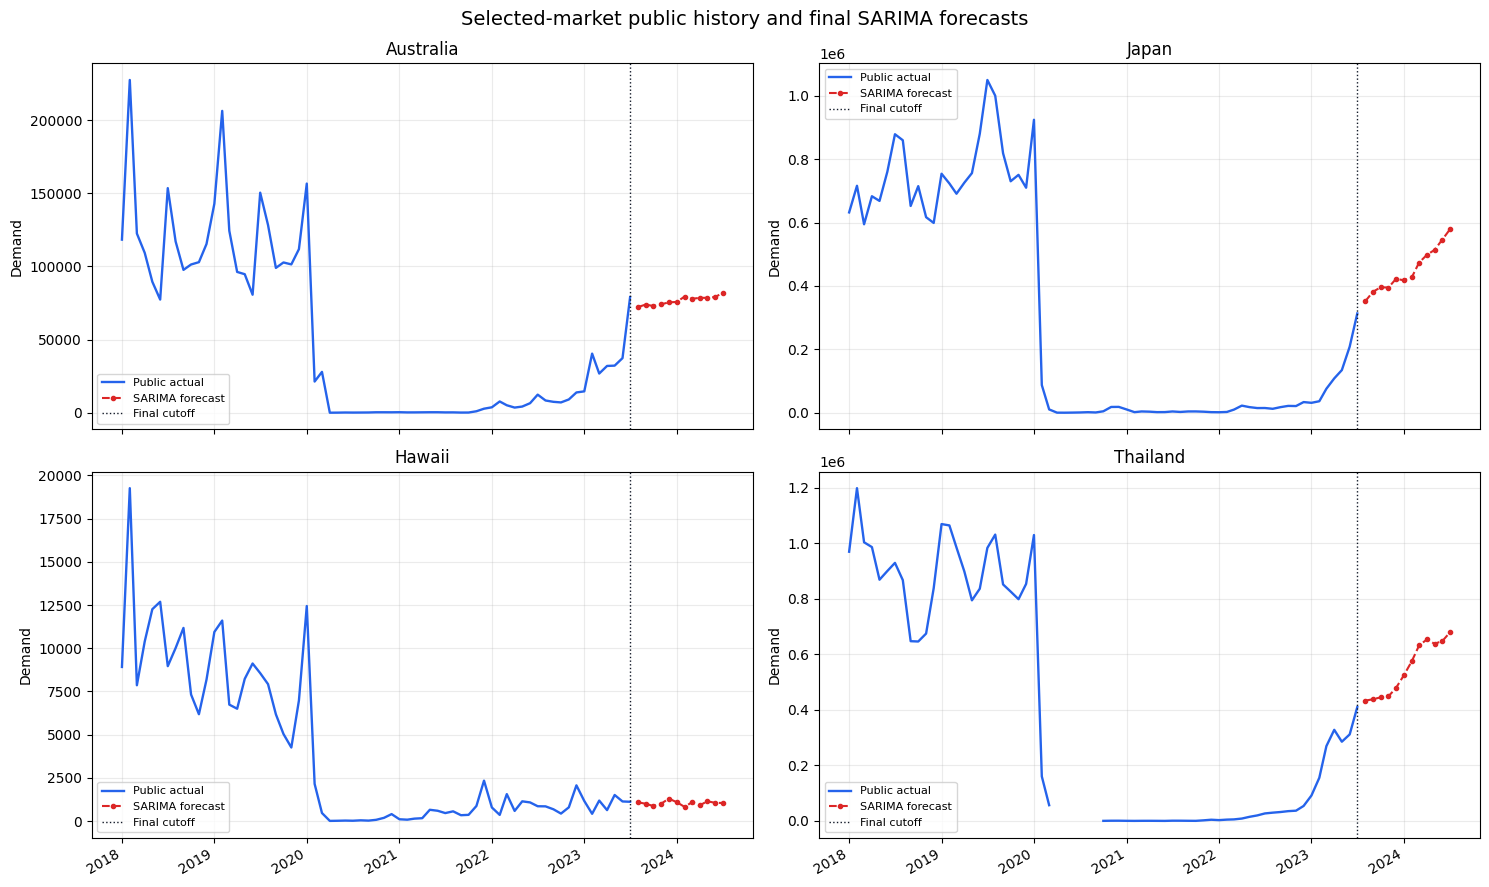

In [ ]:
# Q6 evidence for the two required and two justified additional markets.
SELECTED_MARKETS = ["Australia", "Japan", "Hawaii", "Thailand"]
# predict using all model and take it from odel order
model_display_order = {label: index for index, label in enumerate(model_order)}
# take the resul which we computed in q5
selected_market_validation_table = validation_metrics.loc[
    validation_metrics["destination"].isin(SELECTED_MARKETS),
    [
        "destination", "model_label", "n", "mae", "mase", "mape",
        "denominator", "n_denominator_pairs", "mase_available",
        "denominator_warning",
    ],
].copy()


selected_market_validation_table["_model_order"] = (
    selected_market_validation_table["model_label"].map(model_display_order)
)
# sort by model order and destination
selected_market_validation_table = (
    selected_market_validation_table
    .sort_values(["destination", "_model_order"])
    .drop(columns="_model_order")
    .reset_index(drop=True)
)

history_for_q6 = public_history_wide_to_2023M07.copy()
history_for_q6["_period"] = history_for_q6[
    FINAL_FORECAST_DATE_COLUMN
].map(month_label_to_period)
forecast_for_q6 = forecast_submission_wide.copy()
forecast_for_q6["_period"] = forecast_for_q6[
    FINAL_FORECAST_DATE_COLUMN
].map(month_label_to_period)

# store mean of 2019 2020 2022 and 2023 for each market and store the recovery change percentage
history_summary_rows = []
forecast_summary_rows = []
for market in SELECTED_MARKETS:
    market_history = pd.to_numeric(history_for_q6[market], errors="coerce")
    mean_2019 = market_history[
        history_for_q6["_period"].dt.year == 2019
    ].mean()
    mean_2020 = market_history[
        history_for_q6["_period"].dt.year == 2020
    ].mean()
    mean_2022_mar_jul = market_history[
        history_for_q6["_period"].isin(
            pd.period_range("2022-03", "2022-07", freq="M")
        )
    ].mean()
    mean_2023_mar_jul = market_history[
        history_for_q6["_period"].isin(
            pd.period_range("2023-03", "2023-07", freq="M")
        )
    ].mean()
    history_summary_rows.append({
        "destination": market,
        "mean_2019": mean_2019,
        "mean_2020": mean_2020,
        "mean_2022M03_M07": mean_2022_mar_jul,
        "mean_2023M03_M07": mean_2023_mar_jul,
        "recovery_change_pct": (
            (mean_2023_mar_jul / mean_2022_mar_jul - 1) * 100
            if pd.notna(mean_2022_mar_jul) and mean_2022_mar_jul != 0 else np.nan
        ),
    })

# 12 months forcast 2023M08 onwards
    market_forecast = pd.to_numeric(forecast_for_q6[market], errors="coerce")
    min_position = int(market_forecast.idxmin())
    max_position = int(market_forecast.idxmax())
    first_forecast = float(market_forecast.iloc[0])
    last_forecast = float(market_forecast.iloc[-1])
    forecast_summary_rows.append({
        "destination": market,
        "actual_2023M07": float(market_history.iloc[-1]),
        "forecast_2023M08": first_forecast,
        "forecast_2024M07": last_forecast,
        "minimum_month": forecast_for_q6.loc[min_position, FINAL_FORECAST_DATE_COLUMN],
        "minimum_forecast": float(market_forecast.loc[min_position]),
        "maximum_month": forecast_for_q6.loc[max_position, FINAL_FORECAST_DATE_COLUMN],
        "maximum_forecast": float(market_forecast.loc[max_position]),
        "first_to_last_change_pct": (
            (last_forecast / first_forecast - 1) * 100
            if first_forecast != 0 else np.nan
        ),
    })

selected_market_history_summary = pd.DataFrame(history_summary_rows)
selected_market_forecast_summary = pd.DataFrame(forecast_summary_rows)

display(selected_market_history_summary.round(2))
display(selected_market_validation_table.round(3))
display(selected_market_forecast_summary.round(2))

# plot start period
plot_start = month_label_to_period("2018M01")
fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharex=True)
# plot dor all the selected place
for axis, market in zip(axes.flat, SELECTED_MARKETS):
    visible_history = history_for_q6[history_for_q6["_period"] >= plot_start]
    axis.plot(
        visible_history["_period"].map(lambda period: period.to_timestamp()),
        pd.to_numeric(visible_history[market], errors="coerce"),
        label="Public actual", color="#2563eb", linewidth=1.7,
    )
    # subplot the forecast for the selected model
    axis.plot(
        forecast_for_q6["_period"].map(lambda period: period.to_timestamp()),
        pd.to_numeric(forecast_for_q6[market], errors="coerce"),
        label=f"{selected_model_label.upper()} forecast",
        color="#dc2626", linestyle="--", marker="o", markersize=3,
    )
    axis.axvline(
        month_label_to_period("2023M07").to_timestamp(),
        color="#111827", linestyle=":", linewidth=1, label="Final cutoff",
    )
    axis.set_title(market)
    axis.set_ylabel("Demand")
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)
fig.suptitle("Selected-market public history and final SARIMA forecasts", fontsize=14)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## Part III: Group video and collaboration presentation

### Question 7: Group video and collaboration explanation [15 marks]

Submit an 8-12 minute group video according to the Olympus Assignment requirements. Every group member should participate unless the unit chair has approved an alternative arrangement. The video must show code execution, identify the submitted forecast CSV, explain how the CSV can be regenerated from `forecast_submission_wide`, and let each member explain a meaningful part of the submitted work.

**Required answer markers:** Do not delete, rename, edit, move, or reorder the Q7 START/END marker comments below. Write your response between them.

<!-- A2:ANSWER:Q7:START -->
Record the submitted video filename or link, member participation summary, contribution summary, and any approved alternative arrangement here. Delete this sentence before submission.
<!-- A2:ANSWER:Q7:END -->


## Dataset and external source acknowledgement

This analysis used the **ISF-TDF2023** tourism-demand dataset published by TULIP Lab and obtained from the TULIP Lab Open Data Repository. Only public observations available through the final cutoff of `2023M07` were used for modelling and forecasting. No external datasets, external predictors, or assessment-period actual values were used.

**Dataset reference**

TULIP Lab 2026, *ISF-TDF2023 dataset*, TULIP Lab Open Data Repository, CC BY 4.0, viewed 1 October 2026, <https://github.com/tulip-lab/open-data>.

**Associated publication**

Zhang, Y, Song, B, Li, X, Law, R & Li, G 2026, ‘Imputation recovery tourism demand forecasting’, *Annals of Tourism Research*, vol. 118, article 104144, <https://doi.org/10.1016/j.annals.2026.104144>.


## Submission checklist

Before submitting, check that:

- `GROUP_INFO` is complete and required headings/functions/objects/answer markers are preserved.
- The [A2 Forecast Measures Guide](SIG742-2026T2-A2-Forecast-Measures-Guide.md) has been used for MASE/MAPE handling.
- `None` placeholders have been replaced with completed objects, displayed outputs, or concise evidence summaries.
- The notebook runs top to bottom in a clean runtime and can regenerate the final CSV.
- Random seeds or controlled stochastic behaviour are documented where relevant.
- The PDF includes relevant outputs, figures, tables, and explanations.
- Q1 returns a DataFrame with the required row and column order.
- Q2 returns a dictionary with every key in `Q2_AUDIT_FIELDS` and the required forecast-only `None` values.
- Q3 returns `(destination_metrics, aggregate_metrics)` using `DESTINATION_METRIC_COLUMNS` and `AGGREGATE_METRIC_FIELDS`.
- `baseline_validation_comparison` includes both baselines, all 20 destinations, required measure columns, denominator diagnostics, and row counts.
- `baseline_validation_summary` includes aggregate measures for both baselines.
- `validation_forecasts`, `validation_metrics`, and `model_summary` use their required minimum columns and cover the required models.
- `model_summary` contains exactly one `selected=True` row.
- `forecast_submission_wide` has one `Date` column, exactly 20 destination columns, and exactly 12 rows for `2023M08` to `2024M07`.
- `forecast_submission_audit` contains every Q2 audit key, uses `can_align=None`, and reports `is_valid=True` before export.
- The final forecast CSV is exported directly from `forecast_submission_wide` with `index=False` and no manual post-export edits.
- Forecast values are numeric, finite, destination-specific, and not placeholders or copied actual/result values.
- External data sources are cited, cutoff-safe, and included in `external_data/` where required and permitted.
- No credentials, private data, private paths, or restricted links are included.
- The group video and any contribution material follow Olympus instructions.